# Étude actuarielle — Gravité des accidents corporels à La Réunion pour l'année 2024

---
## Motivation

Originaire des DOM-TOM, j'ai grandi en ayant très peu d'informations sur ces territoires. Des années plus tard, il existe de plus en plus de données mais comparé au reste du territoire français, cela reste insuffisant. Dans cette optique j'ai décidé de créer une série de projets de data visualisation se basant sur des études statistiques avancées avec un thème actuariel assez prononcé. Ce projet sera documenté avec les données dans leur état brut mais aussi raffinées après une préparation de ces données pour les rendre exploitable. Je fournis aussi les données essentielles pour la reproduction des visuels comme les données géographique et routière. 

Je suis actuellement en train de passer mon permis de conduire dans les DOM-TOM et cette situation m'a poussé à m'inquiéter de ma sécurité sur les routes. Pour savoir quels sont les endroits , situations ou comportements à éviter en plus des règles déjà existante à respecter pour sa sureté et celle des autres. J'ai donc décidé d'utiliser mes connaisances en statistiques avec les données réels récupérées auprès du gouvernement. Et tout cela pour répondre à une question en particulier.

### Récemment (ex. en 2024) , quelles sont les causes de risques d'accidents dans un département d'outre mer ?

Dans ce projet pour résoudre notre problématique, nous allons d'abord comment par sélectionner les données que nous allons utiliser. Comme on s'inquiete de accidents corporels, on a naturellement choisi de prendre les données du Bulletin d'Analyse des Accidents Corporels de la circulation publié par le gouvernement français. Mais après études de celles-ci on a décidé d'ajouter en plus de cela des données météorologiques produites par Météo-France.

## Présentation de notre étude 

Afin d’analyser les facteurs de gravité des accidents corporels à La Réunion, plusieurs approches statistiques ont été envisagées. L’objectif n’est pas seulement de prédire la gravité d’un accident, mais aussi de **comprendre les mécanismes qui conduisent à une aggravation des conséquences pour les usagers de la route**.

Dans cette perspective, différents modèles ont été étudiés et comparés selon trois critères principaux :

- leur **capacité à représenter la structure réelle des données**,
- leur **interprétabilité statistique et actuarielle**,  
- leur **adéquation avec les informations disponibles dans le BAAC**.

### Modèles envisagés

| Modèle | Qualités | Limites |
|---|---|---|
| **GLM Logit binaire** | Modèle simple, standard en actuariat, facilement interprétable | Oblige à réduire la gravité en deux catégories (grave / non grave) et mélange plusieurs mécanismes de risque |
| **Modèle ordinal (Proportional Odds)** | Permet de conserver plusieurs niveaux de gravité | Repose sur l’hypothèse de cotes proportionnelles souvent difficile à vérifier dans ce type de données |
| **Elastic Net / modèles pénalisés** | Sélection automatique des variables et gestion de la colinéarité | Moins interprétable dans une perspective actuarielle et tarifaire |
| **Triple Hurdle** | Permettrait de modéliser la probabilité d’accident puis la gravité | Impossible ici : le BAAC ne contient que les accidents, pas l’exposition au risque |

### Modèle retenu : **Double Hurdle**

Au regard de ces éléments, le modèle retenu est un **Double Hurdle**, qui permet de décomposer le risque en deux mécanismes distincts.

L’idée centrale est que **les facteurs qui rendent un accident grave ne sont pas nécessairement les mêmes que ceux qui déterminent la mortalité une fois l’accident grave survenu**.

Le modèle se structure donc en deux étapes :

1. **Hurdle 1 — Probabilité qu’un accident devienne grave**  
   On modélise la probabilité qu’un usager impliqué dans un accident subisse des blessures graves.

2. **Hurdle 2 — Gravité conditionnelle parmi les cas graves**  
   Une fois la gravité atteinte, on analyse les facteurs qui influencent l’issue (hospitalisation, décès).

La logique générale peut se résumer ainsi :

$$
\text{Risque global} =
P(\text{grave} \mid \text{accident})
\times
E[\text{niveau de gravité} \mid \text{grave}]
$$

Cette approche présente plusieurs avantages :

- elle **respecte la structure des données BAAC**, qui ne contiennent que des accidents,
- elle **sépare deux mécanismes de risque distincts**,  
- elle permet d’obtenir des **effets de variables plus interprétables** pour la prévention routière ou l’analyse actuarielle.

Ainsi, le modèle Double Hurdle constitue un compromis pertinent entre **rigueur statistique, interprétabilité et adéquation aux données disponibles**.

---
### Récapitulatif

Pour notre projet nous explorons les données des fichiers du **BAAC 2024** (Bulletin d'Analyse des Accidents Corporels) ainsi que celle du Météo France pour le département 974, avec une approche en trois temps :

1. **Explorer** — On cartographie les accidents sur le territoire, comprendre qui est touché et comment il l'est.
2. **Modéliser** — On utilise un modèle statistique *Double Hurdle* qui structure la réponse à notre question en deux sous questions distinctes :
   - *Hurdle 1* : parmi tous les usagers accidentés, lesquels deviennent des cas graves ?
   - *Hurdle 2* : parmi les cas graves, lesquels décèdent ?
3. **Répondre** — On produit un classement des facteurs de risque et des profils-types.

### Pourquoi séparer en deux étapes et donc le choix d'une structure double hurdle ?

Pour mieux comprendre ce choix voici une petite situation qui illustre notre problématique.

Par je ne sais quel miracle j'ai mon permis. Je décide de conduire la nuit, d'un coup il pleut des cordes et on le sait, en moto, manque de visibilité dit risque accru. Et donc mes chances d'être gravement blessé sont augmentées (Hurdle 1), mais si dans le malheure que cela arrive et que je sois gravement bléssé, d'autre facteur rentrent en compte pour influencer mon pronostic vital. On peut citer l'âge, le type de choc, ou le ports du casque seront les facteurs qui détermineront si oui ou non je survis ou non (Hurdle 2). 
Si on choisissait un modèle unique on mélangerait ces deux méchanismes. Le double hurdle les distingue et les sépare, ce qui permet de cibler les actions de prévention au bon niveau.

## Source des données

L’analyse repose principalement sur les données publiques suivantes :

- **BAAC 2024 — Bulletin d’Analyse des Accidents Corporels de la circulation**  
  Source : ONISR / data.gouv.fr  
  Périmètre : **Département 974 — La Réunion**

Ces données décrivent les caractéristiques détaillées des accidents corporels de la circulation : circonstances, usagers impliqués, gravité des blessures et conditions de l’accident.

## 1. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as pe
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
import seaborn as sns
import os
import urllib.request 
import math
import json

from scipy import stats
from scipy.ndimage import uniform_filter1d
from scipy.stats import chi2_contingency
from scipy.stats import spearmanr
from scipy.stats import chi2
from scipy.stats import mannwhitneyu
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss, classification_report
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder
from statsmodels.miscmodels.ordinal_model import OrderedModel


import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

np.random.seed(42)

## 2. Chargement et regroupement des données BAAC

In [ ]:
caract = pd.read_csv(
    "data/data_raw/caract-2024.csv",
    sep=";",
    dtype={"Num_Acc": str}
)

lieux = pd.read_csv(
    "data/data_raw/lieux-2024.csv",
    sep=";",
    dtype={"Num_Acc": str}
)

usagers = pd.read_csv(
    "data/data_raw/usagers-2024.csv",
    sep=";",
    dtype={"Num_Acc": str}
)

vehicules = pd.read_csv(
    "data/data_raw/vehicules-2024.csv",
    sep=";",
    dtype={"Num_Acc": str}
)


# Filtrer La Réunion
caract_974 = caract[caract["dep"] == "974"].copy()

acc_ids = set(caract_974["Num_Acc"])



baac_df = (
    usagers[usagers["Num_Acc"].isin(acc_ids)]
    .merge(
        caract_974[
            [
                "Num_Acc",
                "com",
                "jour",
                "mois",
                "an",
                "hrmn",
                "lum",
                "agg",
                "int",
                "atm",
                "col",
                "lat",
                "long"
            ]
        ],
        on="Num_Acc",
        how="left"
    )
    .merge(
        lieux[
            [
                "Num_Acc",
                "catr",
                "circ",
                "nbv",
                "surf",
                "infra",
                "situ",
                "vma"
            ]
        ],
        on="Num_Acc",
        how="left"
    )
    .merge(
        vehicules[
            [
                "Num_Acc",
                "id_vehicule",
                "catv",
                "obs",
                "obsm",
                "choc",
                "manv",
                "motor"
            ]
        ],
        on=["Num_Acc","id_vehicule"],
        how="left"
    )
)

print("BAAC dataset :", baac_df.shape)


meteo = pd.read_parquet(
    "data/data_processed/accidents_meteo_features.parquet"
)

meteo["Num_Acc"] = meteo["Num_Acc"].astype(str)

# variables météo utiles
meteo_cols = [
    "Num_Acc",
    "RR1",
    "rain",
    "rain_3h",
    "rain_6h",
    "rain_24h",
    "T"
]

meteo = meteo[meteo_cols]

print("Météo dataset :", meteo.shape)


baac_df = baac_df.merge(
    meteo,
    on="Num_Acc",
    how="left"
)

print("Dataset final :", baac_df.shape)


# valeurs manquantes


na_summary = pd.DataFrame({
    "nb_manquants": baac_df.isna().sum(),
    "pct_manquants": (baac_df.isna().mean()*100).round(2)
}).sort_values("pct_manquants", ascending=False)

print(na_summary.head(20))

baac_df.head()


BAAC dataset : (2565, 41)
Météo dataset : (934, 7)
Dataset final : (2565, 47)
             nb_manquants  pct_manquants
T                     740          28.85
rain_3h               403          15.71
rain_6h               403          15.71
RR1                   403          15.71
rain_24h              397          15.48
an_nais                36           1.40
id_usager               0           0.00
grav                    0           0.00
sexe                    0           0.00
trajet                  0           0.00
Num_Acc                 0           0.00
num_veh                 0           0.00
place                   0           0.00
catu                    0           0.00
id_vehicule             0           0.00
actp                    0           0.00
locp                    0           0.00
secu3                   0           0.00
secu2                   0           0.00
secu1                   0           0.00


,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,...,obsm,choc,manv,motor,RR1,rain,rain_3h,rain_6h,rain_24h,T
0,202400000074,203 988 388,155 781 622,A01,1,1,4,2,2008.0,5,...,2,3,12,5,0.0,0,0.0,0.5,0.5,NaN
1,202400000076,203 988 384,155 781 618,B01,1,1,4,1,2009.0,5,...,2,1,1,1,0.0,0,0.0,0.0,0.0,25.3
2,202400000076,203 988 386,155 781 620,A01,1,1,1,1,1954.0,5,...,2,2,12,1,0.0,0,0.0,0.0,0.0,25.3
3,202400000109,203 988 299,155 781 557,A01,2,2,1,2,2006.0,0,...,1,7,1,1,0.8,1,3.2,3.2,3.2,25.7
4,202400000109,203 988 300,155 781 557,A01,3,2,1,1,2004.0,0,...,1,7,1,1,0.8,1,3.2,3.2,3.2,25.7


## 3. Recodage des variables BAAC

Le BAAC utilise des codes numériques (dictionnaire ONISR). On les traduit en labels lisibles.


### Construction et recodage des variables

Les variables issues de la base **BAAC 2024 (ONISR)** ont été recodées afin de faciliter leur interprétation statistique et d'assurer leur cohérence avec la documentation officielle.

Les libellés des modalités ont été harmonisés conformément à la documentation de référence :

https://www.data.gouv.fr/fr/datasets/bases-de-donnees-annuelles-des-accidents-corporels-de-la-circulation-routiere/

Les principales correspondances utilisées sont présentées ci-dessous.

| Variable | Code | Libellé retenu |
|----------|------|---------------|
| `catv` | 33 | Moto > 125 cm³ |
| `catv` | 34 | Scooter > 125 cm³ |
| `catv` | 37 | Autobus |
| `catv` | 38 | Autocar |
| `catv` | 50 | Engin de déplacement personnel motorisé |
| `lum` | 3 | Nuit sans éclairage public |
| `lum` | 4 | Nuit – éclairage public non allumé |
| `lum` | 5 | Nuit – éclairage public allumé |
| `col` | 6 | Autre collision |
| `col` | 7 | Sans collision |
| `atm` | 6 | Vent fort / tempête |

Ces recodages permettent de garantir une interprétation correcte des variables utilisées dans l’analyse.

---

### Intégration des données météorologiques

Afin d’étudier l’influence des conditions météorologiques sur la gravité des accidents, les données de **Météo-France** ont été intégrées au jeu de données BAAC.

L’appariement a été réalisé selon deux critères :

1. **Proximité géographique**  
   La station météorologique la plus proche de chaque accident a été identifiée à partir des coordonnées géographiques de l’accident.

2. **Correspondance temporelle**  
   Les observations météorologiques horaires ont ensuite été associées à l’heure de l’accident.

Cette procédure permet d’associer à chaque accident les conditions météorologiques observées au moment de sa survenue.

---

### Variables météorologiques utilisées

Plusieurs variables météorologiques ont été intégrées au jeu de données afin de représenter les conditions météorologiques au moment de l’accident.

| Variable | Description |
|----------|-------------|
| `RR1` | Précipitations horaires (mm) |
| `rain` | Indicateur de présence de pluie |
| `rain_3h` | Cumul de pluie sur 3 heures |
| `rain_6h` | Cumul de pluie sur 6 heures |
| `rain_24h` | Cumul de pluie sur 24 heures |
| `T` | Température de l’air (°C) |

Les variables de cumul de pluie permettent notamment de capter l’état potentiel de la chaussée avant l’accident.

---

### Jeu de données analytique final

Le jeu de données analytique final combine les informations :

- des **usagers impliqués dans les accidents**,
- des **caractéristiques des véhicules impliqués**,
- des **caractéristiques de l’accident et de l’infrastructure**,
- des **conditions météorologiques au moment de l’accident**.

L’unité d’observation retenue est **l’usager impliqué dans l’accident**.

Chaque observation contient donc :

- les caractéristiques individuelles de l’usager,
- les caractéristiques du véhicule concerné,
- les caractéristiques de l’accident,
- les conditions météorologiques associées.

In [ ]:
grav_labels = {1: 'indemne', 2: 'tué', 3: 'hospitalisé', 4: 'blessé léger'}
baac_df['grav_label'] = baac_df['grav'].map(grav_labels)

grav_ordinal = {'indemne': 0, 'blessé léger': 1, 'hospitalisé': 2, 'tué': 3}
baac_df['grav_ord'] = baac_df['grav_label'].map(grav_ordinal)

# Hurdle 1 : variable binaire (grave = hospitalisé ou tué)
baac_df['grave'] = baac_df['grav'].isin([2, 3]).astype(int)

print("Distribution de la gravité :")
dist = baac_df['grav_label'].value_counts().reindex(['indemne','blessé léger','hospitalisé','tué'])
for label, count in dist.items():
    print(f"  {label:<15} : {count:>4} ({count/len(baac_df)*100:5.1f}%)")
print(f"\n  → GRAVE (hosp+tué) : {baac_df['grave'].sum()} ({baac_df['grave'].mean()*100:.1f}%)")
print(f"  → Sous-population Hurdle 2 : {baac_df['grave'].sum()} usagers graves")

catv_map = {
    0: 'inconnu',
    1: 'vélo',
    2: 'cyclomoteur <50cm³',
    3: 'voiturette',
    7: 'voiture',
    10: 'utilitaire',
    13: 'poids lourd', 14: 'poids lourd', 15: 'poids lourd',
    16: 'poids lourd', 17: 'poids lourd',
    20: 'engin spécial', 21: 'engin spécial',
    30: 'scooter <50cm³',
    31: 'moto 50-125cm³',
    32: 'scooter 50-125cm³',
    33: 'moto >125cm³',       
    34: 'scooter >125cm³',    
    35: 'quad',               
    36: 'quad',               
    37: 'autobus',            
    38: 'autocar',            
    39: 'train', 40: 'tramway',
    50: 'EDP à moteur',       
    60: 'EDP sans moteur',
    80: 'VAE',
    99: 'autre',
}
baac_df['type_vehicule'] = baac_df['catv'].map(catv_map).fillna('autre')

# Regroupement simplifié pour la modélisation
def type_veh_groupe(x):
    if x in ['vélo', 'VAE']: return 'vélo/VAE'
    if x in ['cyclomoteur <50cm³', 'scooter <50cm³']: return '2RM ≤50cm³'
    if x in ['moto 50-125cm³', 'scooter 50-125cm³']: return '2RM 50-125cm³'
    if x in ['moto >125cm³', 'scooter >125cm³']: return '2RM >125cm³'
    if x == 'voiture': return 'voiture'
    if x == 'utilitaire': return 'utilitaire'
    if x == 'poids lourd': return 'poids lourd'
    if x in ['EDP à moteur', 'EDP sans moteur']: return 'EDP (trottinette)'
    if x in ['autobus', 'autocar']: return 'bus/car'
    return 'autre'

baac_df['type_vehicule'] = baac_df['type_vehicule'].apply(type_veh_groupe)


lum_map = {
    1: 'jour',
    2: 'crépuscule',
    3: 'nuit sans éclairage',     
    4: 'nuit éclairage éteint',   
    5: 'nuit éclairage allumé',   
}
baac_df['eclairage'] = baac_df['lum'].map(lum_map).fillna('inconnu')


def atm_group(x):
    if x == 1: return 'normale'
    if x in [2, 3]: return 'pluie'
    if x == 5: return 'brouillard'
    if x == 6: return 'vent fort'       
    if x == 7: return 'éblouissement'
    if x == 8: return 'couvert'
    return 'autre'
baac_df['atm_groupe'] = baac_df['atm'].apply(atm_group)


baac_df['chaussee_mouillee'] = baac_df['surf'].isin([2, 3, 4]).astype(int)


catr_map = {
    1: 'autoroute', 2: 'nationale', 3: 'départementale',
    4: 'communale', 5: 'hors réseau', 6: 'parking',
    7: 'métropole urbaine', 9: 'autre'
}
baac_df['type_route'] = baac_df['catr'].map(catr_map).fillna('autre')


def col_group(x):
    if x == 1: return 'frontale'
    if x == 2: return 'arrière'
    if x == 3: return 'côté'
    if x == 7: return 'sans collision'   # CORRIGÉ (était col==6)
    return 'autre/multiple'
baac_df['type_collision'] = baac_df['col'].apply(col_group)


baac_df['role'] = baac_df['catu'].map({1: 'conducteur', 2: 'passager', 3: 'piéton'}).fillna('inconnu')
baac_df['equipement'] = baac_df['secu1'].map({
    0: 'sans équipement', 1: 'ceinture', 2: 'casque',
    3: 'dispositif enfant', 4: 'gilet réfléchissant',
    5: 'airbag 2RM', 6: 'gants 2RM', 7: 'gants+airbag 2RM',
    8: 'non déterminable', 9: 'autre'
}).fillna('inconnu')
baac_df['sexe_label'] = baac_df['sexe'].map({1: 'homme', 2: 'femme'}).fillna('inconnu')


baac_df['en_agglomeration'] = (baac_df['agg'] == 2).astype(int)


baac_df['motif'] = baac_df['trajet'].map({
    1: 'domicile-travail', 2: 'domicile-école', 3: 'courses',
    4: 'utilisation pro', 5: 'promenade', 9: 'autre'
}).fillna('inconnu')


baac_df = baac_df.rename(columns={
    "RR1": "pluie_mm",
    "rain": "pluie_presence",
    "rain_3h": "pluie_cumul_3h",
    "rain_6h": "pluie_cumul_6h",
    "rain_24h": "pluie_cumul_24h",
    "T": "temperature"
})

print("\n✓ Recodage ONISR terminé (version corrigée)")
print("  Corrections appliquées :")
print("    - catv 33/34 → moto/scooter >125 (pas quad)")
print("    - catv 37/38 → autobus/autocar (pas quad)")
print("    - catv 50 → EDP à moteur (pas cyclo)")
print("    - lum 3 → nuit SANS éclairage")
print("    - lum 5 → nuit éclairage ALLUMÉ")
print("    - col 6 → autre collision")
print("    - col 7 → sans collision")
print("    - atm 6 → vent fort (séparé du brouillard)")
print()
print(baac_df[['grav_label','type_vehicule','eclairage','atm_groupe','type_route',
          'type_collision','role','sexe_label']].head(3).to_string())

        


Distribution de la gravité :
  indemne         : 1154 ( 45.0%)
  blessé léger    :  982 ( 38.3%)
  hospitalisé     :  386 ( 15.0%)
  tué             :   43 (  1.7%)

  → GRAVE (hosp+tué) : 429 (16.7%)
  → Sous-population Hurdle 2 : 429 usagers graves

✓ Recodage ONISR terminé (version corrigée)
  Corrections appliquées :
    - catv 33/34 → moto/scooter >125 (pas quad)
    - catv 37/38 → autobus/autocar (pas quad)
    - catv 50 → EDP à moteur (pas cyclo)
    - lum 3 → nuit SANS éclairage
    - lum 5 → nuit éclairage ALLUMÉ
    - col 6 → autre collision
    - col 7 → sans collision
    - atm 6 → vent fort (séparé du brouillard)

     grav_label type_vehicule            eclairage atm_groupe type_route  type_collision        role sexe_label
0  blessé léger      vélo/VAE  nuit sans éclairage    normale  communale  autre/multiple  conducteur      femme
1  blessé léger    2RM ≤50cm³           crépuscule    normale  nationale            côté  conducteur      homme
2       indemne       voiture

## 4 Feature engineering

Afin d’enrichir l’analyse et d’améliorer la capacité explicative des modèles, plusieurs variables dérivées ont été construites à partir des variables initiales du jeu de données.

Ces transformations concernent principalement trois dimensions :

- les **caractéristiques météorologiques** associées à l’accident,
- les **caractéristiques démographiques des usagers**,
- les **dimensions temporelles des accidents**.

---

### Variables météorologiques dérivées

Les données météorologiques issues de Météo-France ont été enrichies afin de mieux caractériser les conditions climatiques au moment de l’accident.

#### Indicateur de présence de pluie

Une variable binaire `rain` a été construite afin d’identifier la présence de précipitations au moment de l’accident :

- `1` si des précipitations sont observées (`RR1 > 0`)
- `0` sinon.

Cette variable permet de distinguer les situations de conduite sous pluie.

---

#### Cumuls de précipitations

Afin de capturer l’effet potentiel de l’humidité persistante de la chaussée, plusieurs variables de cumul de pluie ont été utilisées :

| Variable | Description |
|----------|-------------|
| `rain_3h` | cumul de pluie sur les 3 heures précédant l'accident |
| `rain_6h` | cumul de pluie sur les 6 heures précédant l'accident |
| `rain_24h` | cumul de pluie sur les 24 heures précédant l'accident |

Ces variables permettent de mieux représenter l’état de la chaussée avant la survenue de l’accident.

---

#### Transformation des cumuls de pluie

Les variables de cumul de pluie présentent une distribution fortement asymétrique, caractérisée par une forte proportion de valeurs nulles et quelques épisodes de précipitations très intenses.

Afin de réduire l’influence des valeurs extrêmes et d’améliorer la stabilité des estimations économétriques, une transformation logarithmique a été appliquée :

\[
\log(1 + x)
\]

Les variables suivantes ont ainsi été construites :

- `log_rain_3h`
- `log_rain_6h`
- `log_rain_24h`

Cette transformation permet de conserver les observations sans pluie tout en limitant l’impact des épisodes pluvieux extrêmes.

---

### Construction des variables liées à l’âge

L’âge des usagers a été calculé à partir de l’année de l’accident (`an`) et de l’année de naissance (`an_nais`). Les valeurs aberrantes ont été filtrées en conservant uniquement les âges compris entre **5 et 100 ans**.

Afin de capturer les différences de comportement entre classes d’âge, une variable catégorielle `age_groupe` a été construite.

| Groupe d'âge | Intervalle |
|---------------|-------------|
| `<18` | moins de 18 ans |
| `18-25` | jeunes conducteurs |
| `25-35` | jeunes adultes |
| `35-50` | adultes |
| `50-65` | conducteurs expérimentés |
| `65+` | conducteurs seniors |

---

### Construction des variables temporelles

L’heure de l’accident (`hrmn`) a été transformée afin d’extraire l’heure de la journée.

Plusieurs variables temporelles ont ensuite été construites afin de représenter les rythmes de circulation.

#### Variable nuit

Une variable binaire `nuit` a été créée afin d’identifier les accidents survenus pendant la période nocturne :

- `1` si l’accident survient entre **22h et 6h**
- `0` sinon.

---

#### Variable week-end

Une variable binaire `weekend` a été créée afin d’identifier les accidents survenus le **samedi ou le dimanche**, permettant de distinguer les comportements de mobilité liés aux périodes de loisirs.

---

#### Groupes horaires

Afin de mieux représenter les variations de trafic au cours de la journée, l’heure de l’accident a été regroupée en plusieurs catégories :

| Groupe horaire | Intervalle |
|----------------|------------|
| pointe matin | 6h – 9h |
| matin | 9h – 12h |
| déjeuner | 12h – 14h |
| après-midi | 14h – 17h |
| pointe soir | 17h – 20h |
| nuit / soirée | autres heures |

Ces regroupements permettent de capturer les effets liés aux **heures de pointe**, aux **périodes de forte circulation** et aux **périodes nocturnes**.

---

### Variables dérivées utilisées dans l’analyse

Les principales variables construites dans cette étape de feature engineering sont :

- `age`
- `age_groupe`
- `heure`
- `nuit`
- `weekend`
- `heure_groupe`
- `rain`
- `rain_3h`
- `rain_6h`
- `rain_24h`
- `log_rain_3h`
- `log_rain_6h`
- `log_rain_24h`

Ces variables enrichissent la description des accidents en introduisant des dimensions **météorologiques**, **démographiques** et **temporelles** susceptibles d’influencer la gravité des accidents.

In [69]:
# --- Âge ---
baac_df["age"] = pd.to_numeric(baac_df["an"], errors="coerce") - pd.to_numeric(baac_df["an_nais"], errors="coerce")
baac_df["age"] = baac_df["age"].where(baac_df["age"].between(5, 100))

baac_df["age_groupe"] = pd.cut(
    baac_df["age"],
    bins=[5, 18, 25, 35, 50, 65, 100],
    labels=["<18", "18-25", "25-35", "35-50", "50-65", "65+"]
)

# --- Date et temporalité ---
baac_df["date_acc"] = pd.to_datetime(
    baac_df["an"].astype(str) + "-" +
    baac_df["mois"].astype(str).str.zfill(2) + "-" +
    baac_df["jour"].astype(str).str.zfill(2),
    errors="coerce"
)

baac_df["jour_semaine"] = baac_df["date_acc"].dt.dayofweek
baac_df["weekend"] = baac_df["jour_semaine"].isin([5, 6]).astype(int)

# --- Heure ---
baac_df["heure"] = baac_df["hrmn"].astype(str).str.split(":").str[0].replace("nan", np.nan)
baac_df["heure"] = pd.to_numeric(baac_df["heure"], errors="coerce")

baac_df["nuit"] = baac_df["heure"].apply(lambda h: 1 if pd.notna(h) and (h >= 22 or h < 6) else 0)

def heure_groupe(h):
    if pd.isna(h):
        return "inconnu"
    if 6 <= h < 9:
        return "pointe matin"
    if 9 <= h < 12:
        return "matin"
    if 12 <= h < 14:
        return "déjeuner"
    if 14 <= h < 17:
        return "après-midi"
    if 17 <= h < 20:
        return "pointe soir"
    return "nuit/soirée"

baac_df["heure_groupe"] = baac_df["heure"].apply(heure_groupe)

# --- Météo ---
baac_df = baac_df.rename(columns={
    "RR1": "pluie_mm",
    "rain": "pluie_presence",
    "rain_3h": "pluie_cumul_3h",
    "rain_6h": "pluie_cumul_6h",
    "rain_24h": "pluie_cumul_24h",
    "T": "temperature"
})

for col in ["pluie_mm", "pluie_cumul_3h", "pluie_cumul_6h", "pluie_cumul_24h", "temperature"]:
    if col in baac_df.columns:
        baac_df[col] = pd.to_numeric(baac_df[col], errors="coerce")

if "pluie_presence" not in baac_df.columns and "pluie_mm" in baac_df.columns:
    baac_df["pluie_presence"] = (baac_df["pluie_mm"] > 0).astype(int)

# transformation logarithmique
baac_df["log_pluie_3h"] = np.log1p(baac_df["pluie_cumul_3h"])
baac_df["log_pluie_6h"] = np.log1p(baac_df["pluie_cumul_6h"])
baac_df["log_pluie_24h"] = np.log1p(baac_df["pluie_cumul_24h"])

# classes de pluie
baac_df["pluie_6h_classe"] = pd.cut(
    baac_df["pluie_cumul_6h"],
    bins=[-0.01, 0, 2, 10, np.inf],
    labels=["0 mm", "0-2 mm", "2-10 mm", ">10 mm"]
)

baac_df.to_csv(
    "data/data_processed/baac_meteo_dataset.csv",
    index=False,
    encoding="utf-8"
)

---

## 5. Datavisualisation — Les accidents de la route à La Réunion en 2024

Avant de plonger dans la modélisation, il est utile de **prendre du recul** sur les données et de comprendre le contexte réunionnais de l'accidentalité routière.

Cette section propose une série de visualisations accessibles, commentées pour un public non-expert,
qui mettent en lumière les **tendances structurelles** du territoire. Ces observations reviendront
en filigrane dans les résultats du modèle Double Hurdle et dans la conclusion.

> **Lecture guidée** : chaque graphique est accompagné d'un encadré *« Ce qu'il faut retenir »*
> qui résume le message principal en une ou deux phrases.


### 5.1 Géographie de la gravité — Carte communale

La Réunion compte **24 communes** réparties sur un territoire insulaire d'environ 2 500 km².
L'accidentalité routière n'y est pas uniformément distribuée : les grands pôles urbains
(Saint-Denis, Saint-Pierre, Le Port) concentrent naturellement le plus grand nombre d'accidents,
mais **le nombre d'accidents et leur gravité sont deux choses distinctes** —
c'est précisément la philosophie du Double Hurdle.

La carte choroplèthe ci-dessous colore chaque commune selon son **taux de gravité**
(part des usagers hospitalisés ou décédés). Le diagramme en barres à droite classe
les communes pour faciliter la comparaison — une visualisation inspirée des travaux
de cartographie de [R Graph Gallery](https://r-graph-gallery.com/web-choropleth-barchart-map.html).


In [ ]:
GEOJSON_DIR  = os.path.join('.', 'data', 'data_geo')
GEOJSON_PATH = os.path.join(GEOJSON_DIR, 'communes_974.geojson')

URLS = [
    "https://france-geojson.gregoiredavid.fr/repo/departements/974-la-reunion/communes-974-la-reunion.geojson",
    "https://geo.api.gouv.fr/departements/974/communes?format=geojson&geometry=contour",
]

# Téléchargement avec cache 
if not os.path.exists(GEOJSON_PATH):
    os.makedirs(GEOJSON_DIR, exist_ok=True)
    downloaded = False
    for url in URLS:
        try:
            print(f"  Téléchargement depuis : {url[:60]}...")
            urllib.request.urlretrieve(url, GEOJSON_PATH)
            with open(GEOJSON_PATH, 'r') as f:
                geo = json.load(f)
            if len(geo.get('features', [])) >= 20:
                print(f"  ✓ {len(geo['features'])} communes téléchargées.")
                downloaded = True
                break
            else:
                os.remove(GEOJSON_PATH)
        except Exception as e:
            print(f"  ✗ Échec : {e}")
            if os.path.exists(GEOJSON_PATH):
                os.remove(GEOJSON_PATH)
    if not downloaded:
        raise RuntimeError("Impossible de télécharger les contours communaux.")
else:
    with open(GEOJSON_PATH, 'r') as f:
        geo = json.load(f)
    print(f"  ✓ GeoJSON en cache : {len(geo['features'])} communes")

#  Correction codes+noms (bug France-GeoJSON)
COMMUNES_REF = {
    '97401': {'nom': 'Les Avirons',          'lon': 55.330, 'lat': -21.240},
    '97402': {'nom': 'Bras-Panon',           'lon': 55.650, 'lat': -21.020},
    '97403': {'nom': 'Cilaos',               'lon': 55.470, 'lat': -21.130},
    '97404': {'nom': 'Entre-Deux',           'lon': 55.470, 'lat': -21.230},
    '97405': {'nom': "L'Étang-Salé",         'lon': 55.350, 'lat': -21.270},
    '97406': {'nom': 'Petite-Île',           'lon': 55.570, 'lat': -21.350},
    '97407': {'nom': 'Le Port',              'lon': 55.300, 'lat': -20.940},
    '97408': {'nom': 'La Possession',        'lon': 55.350, 'lat': -20.920},
    '97409': {'nom': 'Saint-André',          'lon': 55.660, 'lat': -20.960},
    '97410': {'nom': 'Saint-Benoît',         'lon': 55.700, 'lat': -21.080},
    '97411': {'nom': 'Saint-Denis',          'lon': 55.450, 'lat': -20.880},
    '97412': {'nom': 'Saint-Joseph',         'lon': 55.630, 'lat': -21.370},
    '97413': {'nom': 'Saint-Leu',            'lon': 55.290, 'lat': -21.170},
    '97414': {'nom': 'Saint-Louis',          'lon': 55.420, 'lat': -21.280},
    '97415': {'nom': 'Saint-Paul',           'lon': 55.280, 'lat': -21.020},
    '97416': {'nom': 'Saint-Pierre',         'lon': 55.480, 'lat': -21.330},
    '97417': {'nom': 'Sainte-Marie',         'lon': 55.540, 'lat': -20.900},
    '97418': {'nom': 'Sainte-Rose',          'lon': 55.780, 'lat': -21.150},
    '97419': {'nom': 'Sainte-Suzanne',       'lon': 55.600, 'lat': -20.920},
    '97420': {'nom': 'Le Tampon',            'lon': 55.520, 'lat': -21.250},
    '97421': {'nom': 'Salazie',              'lon': 55.520, 'lat': -21.040},
    '97422': {'nom': 'Trois-Bassins',        'lon': 55.300, 'lat': -21.100},
    '97423': {'nom': 'Plaine-des-Palmistes', 'lon': 55.630, 'lat': -21.150},
    '97424': {'nom': 'Saint-Philippe',       'lon': 55.730, 'lat': -21.360},
}

def _centroid(geometry):
    polys = []
    if geometry['type'] == 'Polygon':
        polys.append(geometry['coordinates'][0])
    elif geometry['type'] == 'MultiPolygon':
        for p in geometry['coordinates']:
            polys.append(p[0])
    if not polys:
        return None, None
    main = max(polys, key=len)
    return sum(p[0] for p in main)/len(main), sum(p[1] for p in main)/len(main)

# Matching glouton par distance centroïde
pairs = []
for code, ref in COMMUNES_REF.items():
    for i, feat in enumerate(geo['features']):
        cx, cy = _centroid(feat['geometry'])
        if cx:
            d = math.sqrt((cx - ref['lon'])**2 + (cy - ref['lat'])**2)
            pairs.append((d, code, i))
pairs.sort()

assignments = {}
used_codes, used_polys = set(), set()
for d, code, idx in pairs:
    if code in used_codes or idx in used_polys:
        continue
    assignments[idx] = code
    used_codes.add(code)
    used_polys.add(idx)

n_fix = 0
for idx, code in assignments.items():
    feat = geo['features'][idx]
    old_code = str(feat['properties'].get('code', ''))
    nom_key = next((k for k in ['nom','NOM','name'] if k in feat['properties']), 'nom')
    if old_code != code or feat['properties'].get(nom_key) != COMMUNES_REF[code]['nom']:
        feat['properties']['code'] = code
        feat['properties'][nom_key] = COMMUNES_REF[code]['nom']
        n_fix += 1

print(f"  🔧 {n_fix} polygones corrigés (codes INSEE + noms)")

  ✓ GeoJSON en cache : 24 communes
  🔧 4 polygones corrigés (codes INSEE + noms)


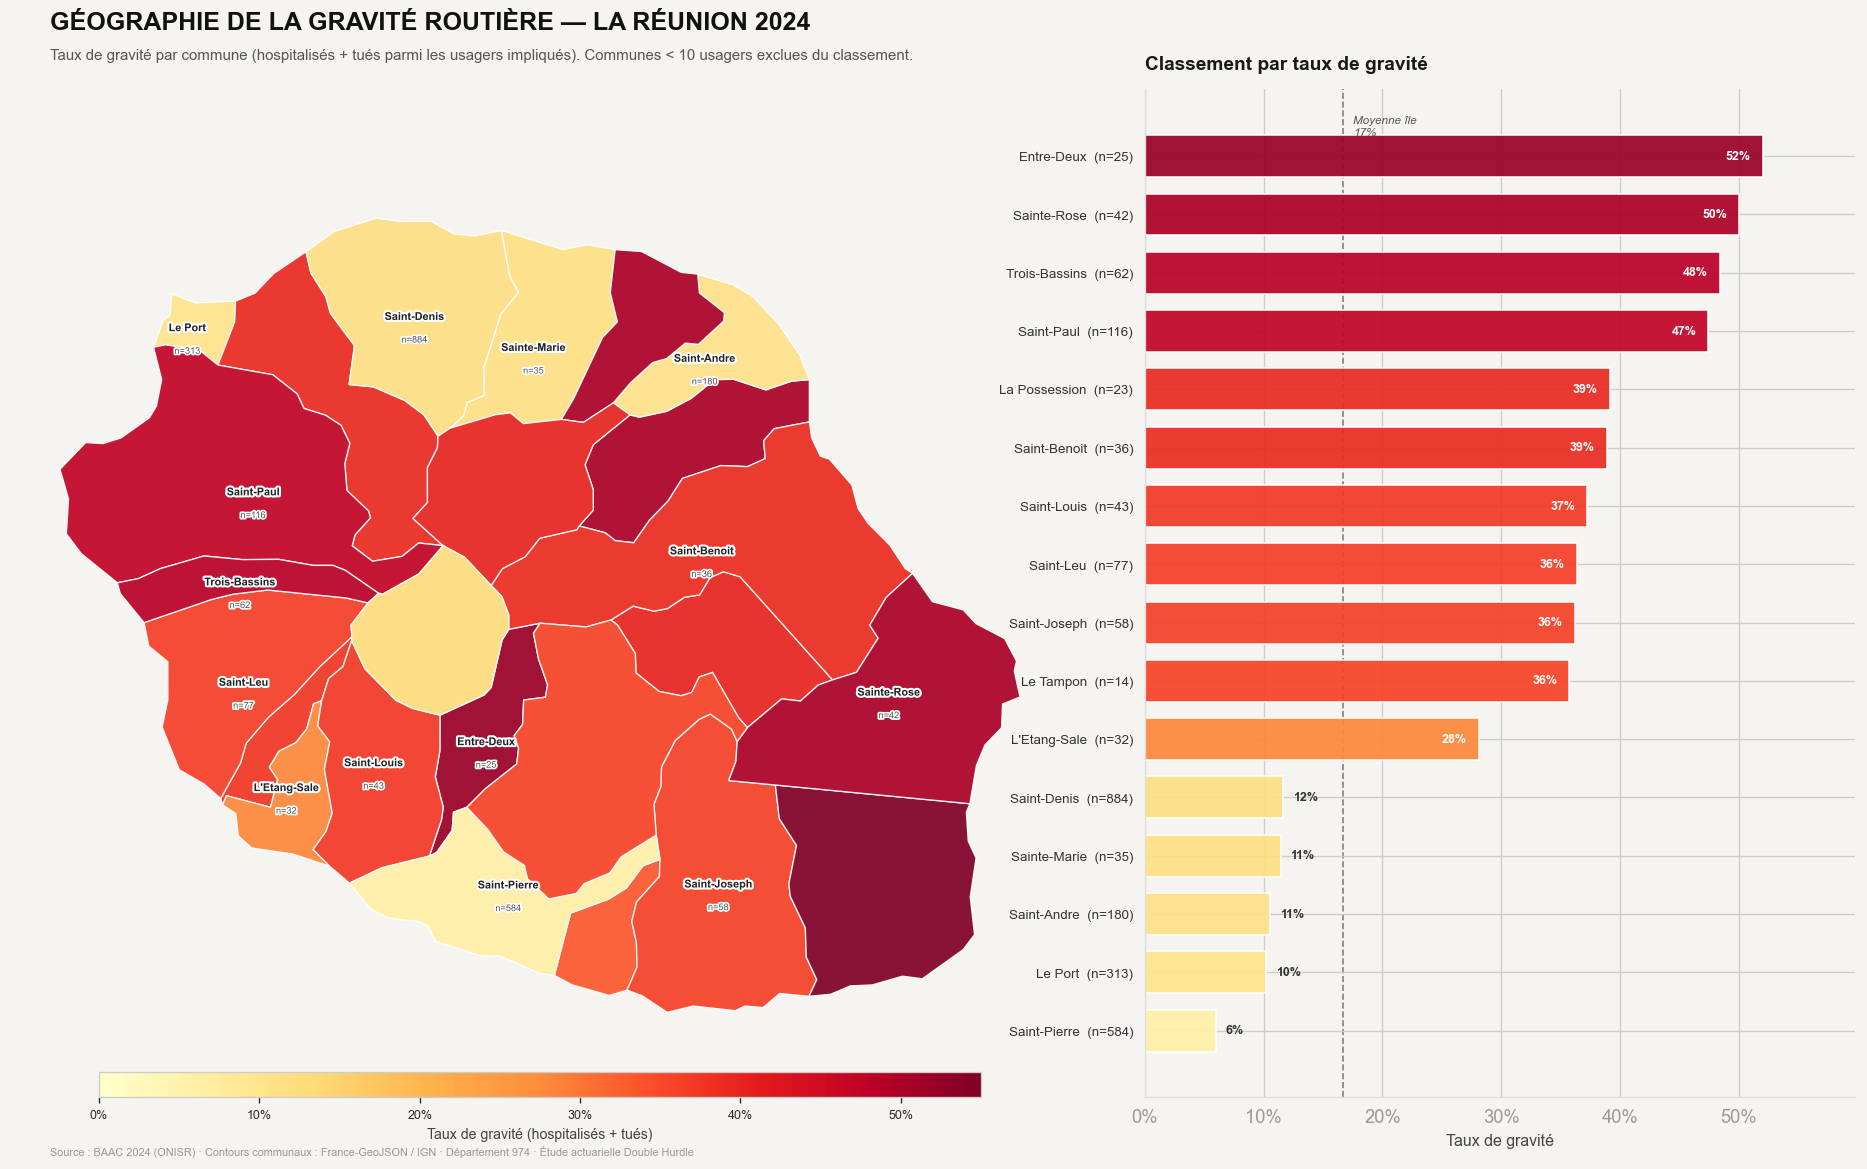

In [71]:
# ═══════════════════════════════════════════════════════════════════════
# CARTE CHOROPLÈTHE — Taux de gravité par commune · La Réunion 2024
# Inspiré de : r-graph-gallery.com/web-choropleth-barchart-map.html
# ═══════════════════════════════════════════════════════════════════════
#
# Pas besoin de geopandas : on parse le GeoJSON à la main et on dessine
# les polygones directement avec matplotlib (PatchCollection).
# ═══════════════════════════════════════════════════════════════════════

# ── 1. Charger le GeoJSON ──────────────────────────────────────────────
with open(GEOJSON_PATH, 'r') as f:
    geo = json.load(f)

# ── 2. Extraire les polygones et codes INSEE ───────────────────────────
# Le GeoJSON peut avoir des clés différentes selon la source
# On cherche le code commune dans les propriétés
def get_code(props):
    """Extraire le code INSEE depuis les propriétés GeoJSON."""
    for key in ['code', 'codgeo', 'CODE', 'insee', 'INSEE_COM', 'code_commune']:
        if key in props:
            return str(props[key])
    # Fallback : chercher un champ qui ressemble à un code 974xx
    for k, v in props.items():
        if isinstance(v, str) and v.startswith('974') and len(v) == 5:
            return v
    return None

def get_name(props):
    """Extraire le nom de commune depuis les propriétés GeoJSON."""
    for key in ['nom', 'NOM', 'name', 'NOM_COM', 'lib']:
        if key in props:
            return str(props[key])
    return '?'

def extract_polygons(geometry):
    """
    Extraire une liste de tableaux de coordonnées (lon, lat) depuis
    un objet geometry GeoJSON (Polygon ou MultiPolygon).
    """
    polys = []
    if geometry['type'] == 'Polygon':
        # Un seul anneau extérieur (le premier ring)
        coords = np.array(geometry['coordinates'][0])
        polys.append(coords)
    elif geometry['type'] == 'MultiPolygon':
        for polygon in geometry['coordinates']:
            coords = np.array(polygon[0])
            polys.append(coords)
    return polys

# ── 3. Statistiques par commune ────────────────────────────────────────
stats_com = baac_df.groupby('com').agg(
    n_usagers=('grave', 'count'),
    n_graves=('grave', 'sum'),
).reset_index()
stats_com['taux_grav'] = stats_com['n_graves'] / stats_com['n_usagers']
stats_com['com'] = stats_com['com'].astype(str).str.strip()
stats_dict = stats_com.set_index('com')[['n_usagers', 'n_graves', 'taux_grav']].to_dict('index')

taux_global = baac_df['grave'].mean()

# ── 4. Style ───────────────────────────────────────────────────────────
BG = '#F5F4F0'
cmap = plt.cm.YlOrRd
vmin, vmax = 0.0, 0.55  # plage du taux de gravité pour la colormap
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# ── 5. Figure composite ───────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10), facecolor=BG)
ax_map = fig.add_axes([0.01, 0.06, 0.55, 0.84], facecolor=BG)
ax_bar = fig.add_axes([0.60, 0.06, 0.37, 0.84], facecolor=BG)

# ── 6. CARTE CHOROPLÈTHE ──────────────────────────────────────────────
# On dessine chaque commune comme un polygone coloré par taux de gravité
commune_data = []  # pour le barchart ensuite

for feature in geo['features']:
    props = feature['properties']
    code = get_code(props)
    nom  = get_name(props)
    if code is None:
        continue

    polygons = extract_polygons(feature['geometry'])
    stats = stats_dict.get(code, None)

    if stats is not None:
        taux = stats['taux_grav']
        n_us = stats['n_usagers']
        color = cmap(norm(taux))
        commune_data.append({
            'code': code, 'nom': nom, 'taux': taux, 'n': n_us,
            'n_graves': stats['n_graves']
        })
    else:
        # Commune sans accident dans nos données → gris clair
        taux = None
        color = '#E0DDD8'
        n_us = 0

    for coords in polygons:
        poly = MplPolygon(
            coords, closed=True,
            facecolor=color,
            edgecolor='white',
            linewidth=0.8,
            alpha=0.92,
            zorder=2
        )
        ax_map.add_patch(poly)

    # Labels pour les communes avec données
    if stats is not None and n_us >= 25:
        # Calcul du centroïde approximatif (moyenne des sommets du plus grand polygone)
        main_poly = max(polygons, key=len)
        cx = main_poly[:, 0].mean()
        cy = main_poly[:, 1].mean()

        # Texte en 2 lignes : nom + effectif
        label_text = f"{nom}"
        ax_map.text(
            cx, cy, label_text,
            fontsize=6.5, fontweight='bold', color='#222',
            ha='center', va='center', zorder=10,
            path_effects=[pe.withStroke(linewidth=2.5, foreground='white')]
        )
        # Effectif en dessous, plus petit
        ax_map.text(
            cx, cy - 0.012, f"n={n_us}",
            fontsize=5.5, color='#555',
            ha='center', va='top', zorder=10,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')]
        )

# Ajustement automatique des limites
ax_map.autoscale_view()
ax_map.set_aspect('equal')
for spine in ax_map.spines.values():
    spine.set_visible(False)
ax_map.set_xticks([])
ax_map.set_yticks([])

# Colorbar horizontale sous la carte
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_map, orientation='horizontal',
                     fraction=0.025, pad=0.02, aspect=35)
cbar.set_label('Taux de gravité (hospitalisés + tués)', fontsize=8.5, color='#444')
cbar.ax.tick_params(labelsize=7.5)
cbar.ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# ── 7. BARCHART (panneau droit) ────────────────────────────────────────
# Trier les communes par taux de gravité croissant
df_bar = pd.DataFrame(commune_data)
df_bar = df_bar[df_bar['n'] >= 10].sort_values('taux', ascending=True).reset_index(drop=True)

y_pos = range(len(df_bar))
colors_bar = [cmap(norm(t)) for t in df_bar['taux']]

ax_bar.barh(
    list(y_pos), df_bar['taux'].values,
    color=colors_bar, edgecolor='white', height=0.72, alpha=0.92
)

# Ligne de référence : taux moyen global
ax_bar.axvline(taux_global, color='#333', linestyle='--', linewidth=1, alpha=0.6, zorder=0)
ax_bar.text(
    taux_global + 0.008, len(df_bar) - 0.3,
    f'Moyenne île\n{taux_global:.0%}',
    fontsize=7, color='#555', va='top', fontstyle='italic'
)

# Labels des communes (nom + effectif)
labels_bar = [f"{row['nom']}  (n={row['n']})" for _, row in df_bar.iterrows()]
ax_bar.set_yticks(list(y_pos))
ax_bar.set_yticklabels(labels_bar, fontsize=8, color='#333')

# Pourcentage sur chaque barre
for i, (_, row) in enumerate(df_bar.iterrows()):
    t = row['taux']
    # Texte à l'intérieur si la barre est assez longue, sinon à l'extérieur
    if t > 0.12:
        ax_bar.text(t - 0.01, i, f'{t:.0%}', va='center', ha='right',
                    fontsize=7.5, fontweight='bold',
                    color='white' if t > 0.25 else '#333')
    else:
        ax_bar.text(t + 0.008, i, f'{t:.0%}', va='center', ha='left',
                    fontsize=7.5, fontweight='bold', color='#333')

ax_bar.set_xlabel('Taux de gravité', fontsize=9.5, color='#444')
ax_bar.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax_bar.set_xlim(0, df_bar['taux'].max() * 1.15)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.spines['left'].set_color('#DDD')
ax_bar.spines['bottom'].set_color('#DDD')
ax_bar.tick_params(axis='x', colors='#999', length=3)
ax_bar.set_title(
    'Classement par taux de gravité',
    fontsize=11.5, fontweight='bold', color='#1a1a1a', pad=12, loc='left'
)

# ── 8. Titre & sous-titre ─────────────────────────────────────────────
fig.text(
    0.03, 0.95,
    'GÉOGRAPHIE DE LA GRAVITÉ ROUTIÈRE — LA RÉUNION 2024',
    fontsize=15, fontweight='bold', color='#111'
)
fig.text(
    0.03, 0.925,
    'Taux de gravité par commune (hospitalisés + tués parmi les usagers impliqués). '
    'Communes < 10 usagers exclues du classement.',
    fontsize=9, color='#555'
)
fig.text(
    0.03, 0.012,
    'Source : BAAC 2024 (ONISR) · Contours communaux : France-GeoJSON / IGN · '
    'Département 974 · Étude actuarielle Double Hurdle',
    fontsize=6.5, color='#999'
)

plt.show()


> **Ce qu'il faut retenir :**
>
> Saint-Denis et Saint-Pierre concentrent à eux seuls plus de la moitié des usagers accidentés,
> ce qui reflète leur poids démographique. Mais le **taux de gravité** raconte une autre histoire :
> certaines communes rurales ou périurbaines, avec moins d'accidents, affichent une proportion
> nettement plus élevée de cas graves. C'est exactement ce que le modèle Double Hurdle
> permettra de décomposer : la **fréquence** (combien d'accidents ?) et la **sévérité**
> (quelle proportion est grave ?) n'obéissent pas aux mêmes déterminants.
>
> On note par exemple que les communes traversées par des axes rapides hors agglomération
> (routes départementales et nationales) tendent à avoir un taux de gravité supérieur à la moyenne.
> Cette observation préfigure les résultats du Hurdle 1 (section 7), où le type de route et la
> vitesse maximale autorisée ressortent comme facteurs aggravants.


### 5.2 Quand surviennent les accidents ? — Le rythme temporel

L'accidentalité routière suit un rythme — quotidien, hebdomadaire, saisonnier —
qui reflète les habitudes de déplacement du territoire. La Réunion, avec ses spécificités
(climat tropical, saison des pluies de décembre à mars, fêtes et vacances locales),
présente un profil temporel qui lui est propre.

Les trois graphiques ci-dessous explorent cette dimension sous trois angles complémentaires.


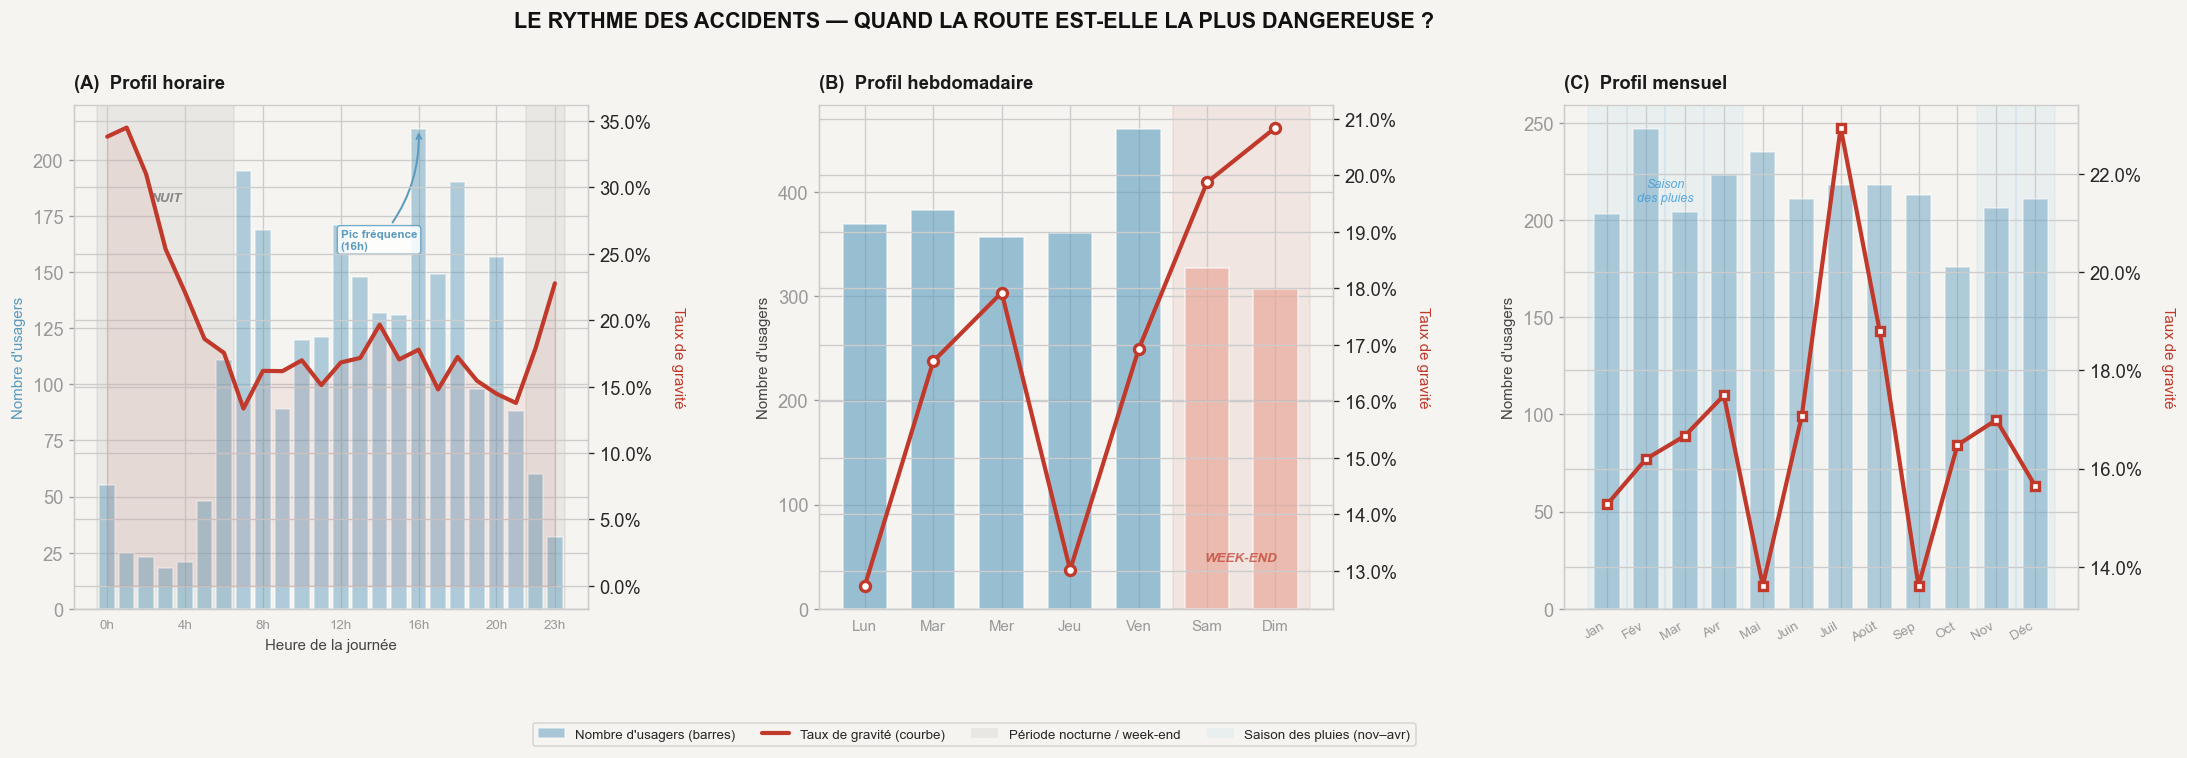

In [ ]:
BG = '#F5F4F0'
C_FREQ = '#5B9BBD'
C_GRAV = '#C0392B'
C_GRAV_LIGHT = '#E8A090'

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=BG)
for ax in axes:
    ax.set_facecolor(BG)

#  (A) PROFIL HORAIRE ─
h_stats = baac_df.groupby('heure').agg(
    n=('grave', 'count'),
    taux=('grave', 'mean')
).reset_index().dropna()

ax = axes[0]
ax2 = ax.twinx()

bars = ax.bar(h_stats['heure'], h_stats['n'], color=C_FREQ, alpha=0.45,
              edgecolor='white', width=0.8, zorder=2)


taux_smooth = uniform_filter1d(h_stats['taux'].values.astype(float), size=3)
ax2.plot(h_stats['heure'], taux_smooth, color=C_GRAV, linewidth=2.5, zorder=3)
ax2.fill_between(h_stats['heure'], taux_smooth, alpha=0.08, color=C_GRAV, zorder=1)

for start, end in [(0, 6), (22, 23)]:
    ax.axvspan(start - 0.5, end + 0.5, alpha=0.06, color='#1a1a1a', zorder=0)
ax.text(3, h_stats['n'].max() * 0.85, 'NUIT', fontsize=8, color='#888', ha='center',
        fontweight='bold', fontstyle='italic')

ax.set_xlabel('Heure de la journée', fontsize=9, color='#444')
ax.set_ylabel("Nombre d'usagers", fontsize=9, color=C_FREQ)
ax2.set_ylabel('Taux de gravité', fontsize=9, color=C_GRAV, rotation=270, labelpad=20)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xticks([0, 4, 8, 12, 16, 20, 23])
ax.set_xticklabels(['0h', '4h', '8h', '12h', '16h', '20h', '23h'], fontsize=8)
ax.set_title('(A)  Profil horaire', fontsize=11, fontweight='bold',
              color='#1a1a1a', pad=10, loc='left')


h_pic_freq = h_stats.loc[h_stats['n'].idxmax(), 'heure']
ax.annotate(
    f'Pic fréquence\n({int(h_pic_freq)}h)',
    xy=(h_pic_freq, h_stats['n'].max()),
    xytext=(h_pic_freq - 4, h_stats['n'].max() * 0.75),
    fontsize=7,
    color=C_FREQ,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=C_FREQ, alpha=0.85, lw=0.8),
    arrowprops=dict(
        arrowstyle='->',
        color=C_FREQ,
        lw=1.2,
        connectionstyle='arc3,rad=0.2'
    )
)

# (B) PROFIL HEBDOMADAIRE 
baac_df['date_str'] = (baac_df['an'].astype(str) + '-' +
                       baac_df['mois'].astype(str).str.zfill(2) + '-' +
                       baac_df['jour'].astype(str).str.zfill(2))
baac_df['date'] = pd.to_datetime(baac_df['date_str'], format='%Y-%m-%d', errors='coerce')
baac_df['jour_sem'] = baac_df['date'].dt.dayofweek

jours_labels = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
j_stats = baac_df.groupby('jour_sem').agg(
    n=('grave', 'count'),
    taux=('grave', 'mean')
).reindex(range(7)).reset_index()

ax = axes[1]
ax2b = ax.twinx()

colors_j = [C_GRAV_LIGHT if j >= 5 else C_FREQ for j in range(7)]
ax.bar(j_stats['jour_sem'], j_stats['n'], color=colors_j, alpha=0.6,
       edgecolor='white', width=0.65, zorder=2)

ax2b.plot(j_stats['jour_sem'], j_stats['taux'], color=C_GRAV,
          linewidth=2.5, marker='o', markersize=6, zorder=3,
          markerfacecolor='white', markeredgecolor=C_GRAV, markeredgewidth=2)

ax.axvspan(4.5, 6.5, alpha=0.08, color=C_GRAV, zorder=0)


ax.text(5.5, j_stats['n'].max() * 0.1, 'WEEK-END',
        fontsize=8, color=C_GRAV, ha='center',
        fontweight='bold', fontstyle='italic', alpha=0.7)

ax.set_xticks(range(7))
ax.set_xticklabels(jours_labels, fontsize=9)
ax.set_ylabel("Nombre d'usagers", fontsize=9, color='#444')
ax2b.set_ylabel('Taux de gravité', fontsize=9, color=C_GRAV, rotation=270, labelpad=20)
ax2b.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('(B)  Profil hebdomadaire', fontsize=11, fontweight='bold',
              color='#1a1a1a', pad=10, loc='left')

# (C) PROFIL MENSUEL
m_stats = baac_df.groupby('mois').agg(
    n=('grave', 'count'),
    taux=('grave', 'mean')
).reindex(range(1, 13)).reset_index()
m_stats['mois'] = m_stats['mois'].astype(int)

mois_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin',
               'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

ax = axes[2]
ax2c = ax.twinx()

for m in [1, 2, 3, 4, 11, 12]:
    ax.axvspan(m - 0.5, m + 0.5, alpha=0.06, color='#3498db', zorder=0)

ax.bar(m_stats['mois'], m_stats['n'], color=C_FREQ, alpha=0.45,
       edgecolor='white', width=0.65, zorder=2)
ax2c.plot(m_stats['mois'], m_stats['taux'], color=C_GRAV,
          linewidth=2.5, marker='s', markersize=5, zorder=3,
          markerfacecolor='white', markeredgecolor=C_GRAV, markeredgewidth=2)

ax.text(2.5, m_stats['n'].max() * 0.85, 'Saison\ndes pluies',
        fontsize=7.5, color='#3498db',
        ha='center', fontstyle='italic', alpha=0.8)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_labels, fontsize=8, rotation=30, ha='right')
ax.set_ylabel("Nombre d'usagers", fontsize=9, color='#444')
ax2c.set_ylabel('Taux de gravité', fontsize=9, color=C_GRAV, rotation=270, labelpad=20)
ax2c.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('(C)  Profil mensuel', fontsize=11, fontweight='bold',
              color='#1a1a1a', pad=10, loc='left')

for a in axes:
    a.spines['top'].set_visible(False)
    a.tick_params(axis='both', colors='#999', length=3)

# Légende 
legend_elements = [
    mpatches.Patch(fc=C_FREQ, alpha=0.5, label="Nombre d'usagers (barres)"),
    plt.Line2D([0], [0], color=C_GRAV, linewidth=2.5, label='Taux de gravité (courbe)'),
    mpatches.Patch(fc='#1a1a1a', alpha=0.06, label='Période nocturne / week-end'),
    mpatches.Patch(fc='#3498db', alpha=0.06, label='Saison des pluies (nov–avr)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=8,
           framealpha=0.7, bbox_to_anchor=(0.5, -0.02), facecolor=BG, edgecolor='#CCC')

fig.suptitle('LE RYTHME DES ACCIDENTS — QUAND LA ROUTE EST-ELLE LA PLUS DANGEREUSE ?',
             fontsize=13, fontweight='bold', color='#111', y=1.01)

plt.subplots_adjust(bottom=0.18, top=0.88, wspace=0.45, right=0.96)

#plt.savefig(
#    "triptyque_accidents.png",
#    dpi=600,
#    bbox_inches='tight',
#    facecolor=fig.get_facecolor()
#)
plt.show()

> **Ce qu'il faut retenir — Trois rythmes, un même constat :**
>
> **(A) Le paradoxe horaire.** Les accidents sont les plus fréquents aux heures de pointe
> (8h–9h et 16h–18h), quand la circulation est dense. Mais le taux de gravité est plus
> élevé la nuit et en début de matinée, quand les vitesses sont plus élevées et la visibilité
> réduite. C'est une illustration directe de ce que le Double Hurdle va quantifier :
> la *fréquence* des accidents (Hurdle 1) ne suit pas le même schéma que la *sévérité
> conditionnelle* (Hurdle 2).
>
> **(B) L'effet week-end.** Le samedi et le dimanche présentent un taux de gravité sensiblement
> différent des jours de semaine. Les trajets de loisirs, souvent sur des routes à vitesse
> plus élevée, remplacent les courts trajets urbains domicile–travail. Ce contraste
> se retrouvera dans les variables `motif` et `en_agglomeration` du modèle.
>
> **(C) Pas de saisonnalité marquée pour la gravité.** Si la saison des pluies (novembre à avril)
> augmente légèrement la fréquence des accidents (chaussée mouillée, visibilité),
> le taux de gravité ne suit pas la même logique — les mois les plus meurtriers ne sont
> pas nécessairement les plus pluvieux. Le modèle testera cette hypothèse via la variable
> `chaussee_mouillee` et `atm_groupe`.


### 5.4 Synthèse visuelle — Ce que les données nous disent avant le modèle

Les trois visualisations précédentes mettent en évidence un **constat central** :
les facteurs qui déterminent la *fréquence* des accidents ne sont pas les mêmes que ceux
qui déterminent leur *gravité*. Ce découplage est visible dans :

- la **carte communale**, où les communes les plus accidentées ne sont pas les plus
  dangereuses en proportion ;
- le **triptyque temporel**, où les heures de pointe (forte fréquence) ne coïncident pas
  avec les heures les plus meurtrières (forte gravité) ;

C'est précisément cette dissociation fréquence–sévérité qui justifie le recours à un
**modèle Double Hurdle** : un premier étage pour modéliser *si* l'accident est grave,
un second pour modéliser *à quel point* il l'est. La section suivante (EDA statistique)
va formaliser ces intuitions visuelles avant de passer à la modélisation.

---


## 6. Analyse exploratoire (EDA)

### 6.1 Structure de la sinistralité et justification du Double Hurdle

> **Point clé** : si les facteurs de risque pour *devenir grave* (Hurdle 1) diffèrent des facteurs
> déterminant *l'intensité de la gravité* (Hurdle 2), alors un modèle unique est mal spécifié.
> L'EDA va nous permettre de vérifier cette hypothèse avant même de modéliser.


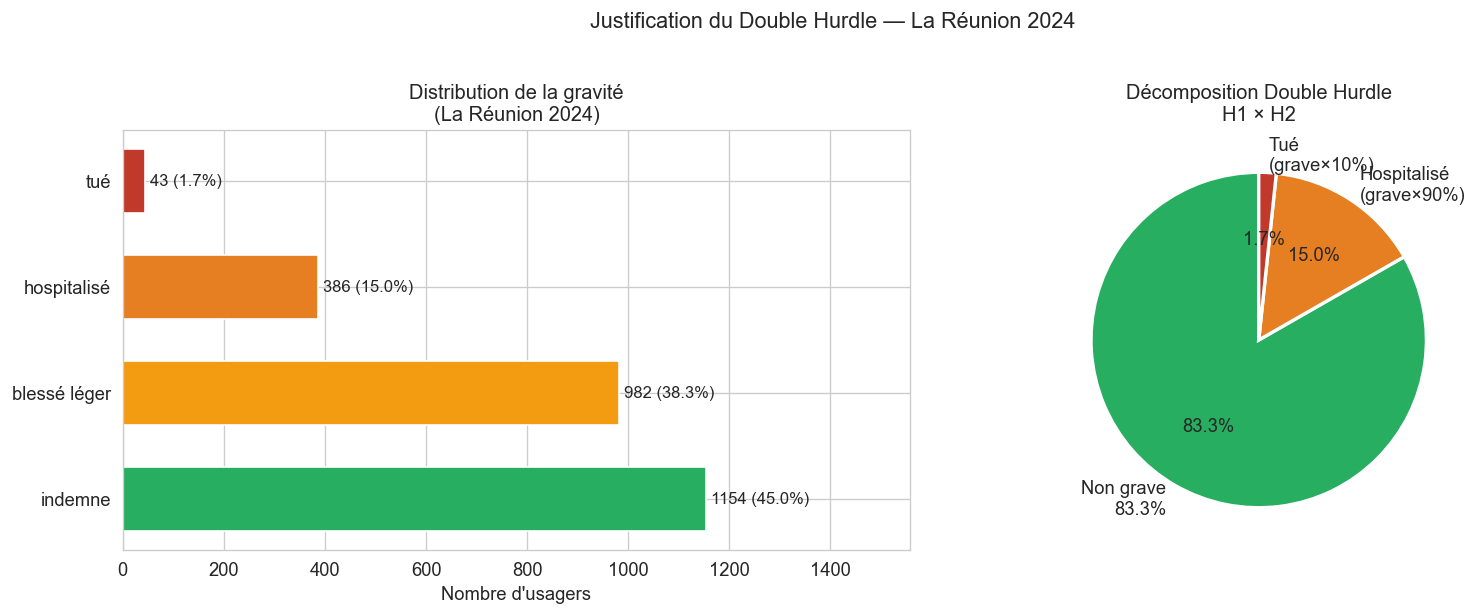

Hurdle 1 — P(grave | accident)       : 16.7%
Hurdle 2 — P(hospitalisé | grave)     : 90.0%
Hurdle 2 — P(tué | grave)             : 10.0%

→ La sous-population grave (429 usagers) sera modélisée séparément au Hurdle 2


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order_grav = ['indemne', 'blessé léger', 'hospitalisé', 'tué']
colors_grav = ['#27ae60', '#f39c12', '#e67e22', '#c0392b']
counts = baac_df['grav_label'].value_counts().reindex(order_grav)

bars = axes[0].barh(order_grav, counts.values, color=colors_grav, edgecolor='white', height=0.6)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/len(baac_df)*100:.1f}%)', va='center', fontsize=10)
axes[0].set_title('Distribution de la gravité\n(La Réunion 2024)', fontsize=12)
axes[0].set_xlabel("Nombre d'usagers")
axes[0].set_xlim(0, counts.max() * 1.35)

# Décomposition Double Hurdle — proportions
h1 = baac_df['grave'].mean()
h2_hosp = baac_df[baac_df['grave']==1]['grav_label'].value_counts(normalize=True).get('hospitalisé', 0)
h2_tue  = baac_df[baac_df['grave']==1]['grav_label'].value_counts(normalize=True).get('tué', 0)

wedge_data = [1 - h1, h1 * h2_hosp, h1 * h2_tue]
wedge_labels = [f'Non grave\n{1-h1:.1%}', f'Hospitalisé\n(grave×{h2_hosp:.0%})', f'Tué\n(grave×{h2_tue:.0%})']
wedge_colors = ['#27ae60', '#e67e22', '#c0392b']
axes[1].pie(wedge_data, labels=wedge_labels, colors=wedge_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Décomposition Double Hurdle\nH1 × H2', fontsize=12)

plt.suptitle('Justification du Double Hurdle — La Réunion 2024', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Hurdle 1 — P(grave | accident)       : {h1:.1%}")
print(f"Hurdle 2 — P(hospitalisé | grave)     : {h2_hosp:.1%}")
print(f"Hurdle 2 — P(tué | grave)             : {h2_tue:.1%}")
print(f"\n→ La sous-population grave ({baac_df['grave'].sum()} usagers) sera modélisée séparément au Hurdle 2")


### 6.2 Comparaison des facteurs de risque : Hurdle 1 vs Hurdle 2

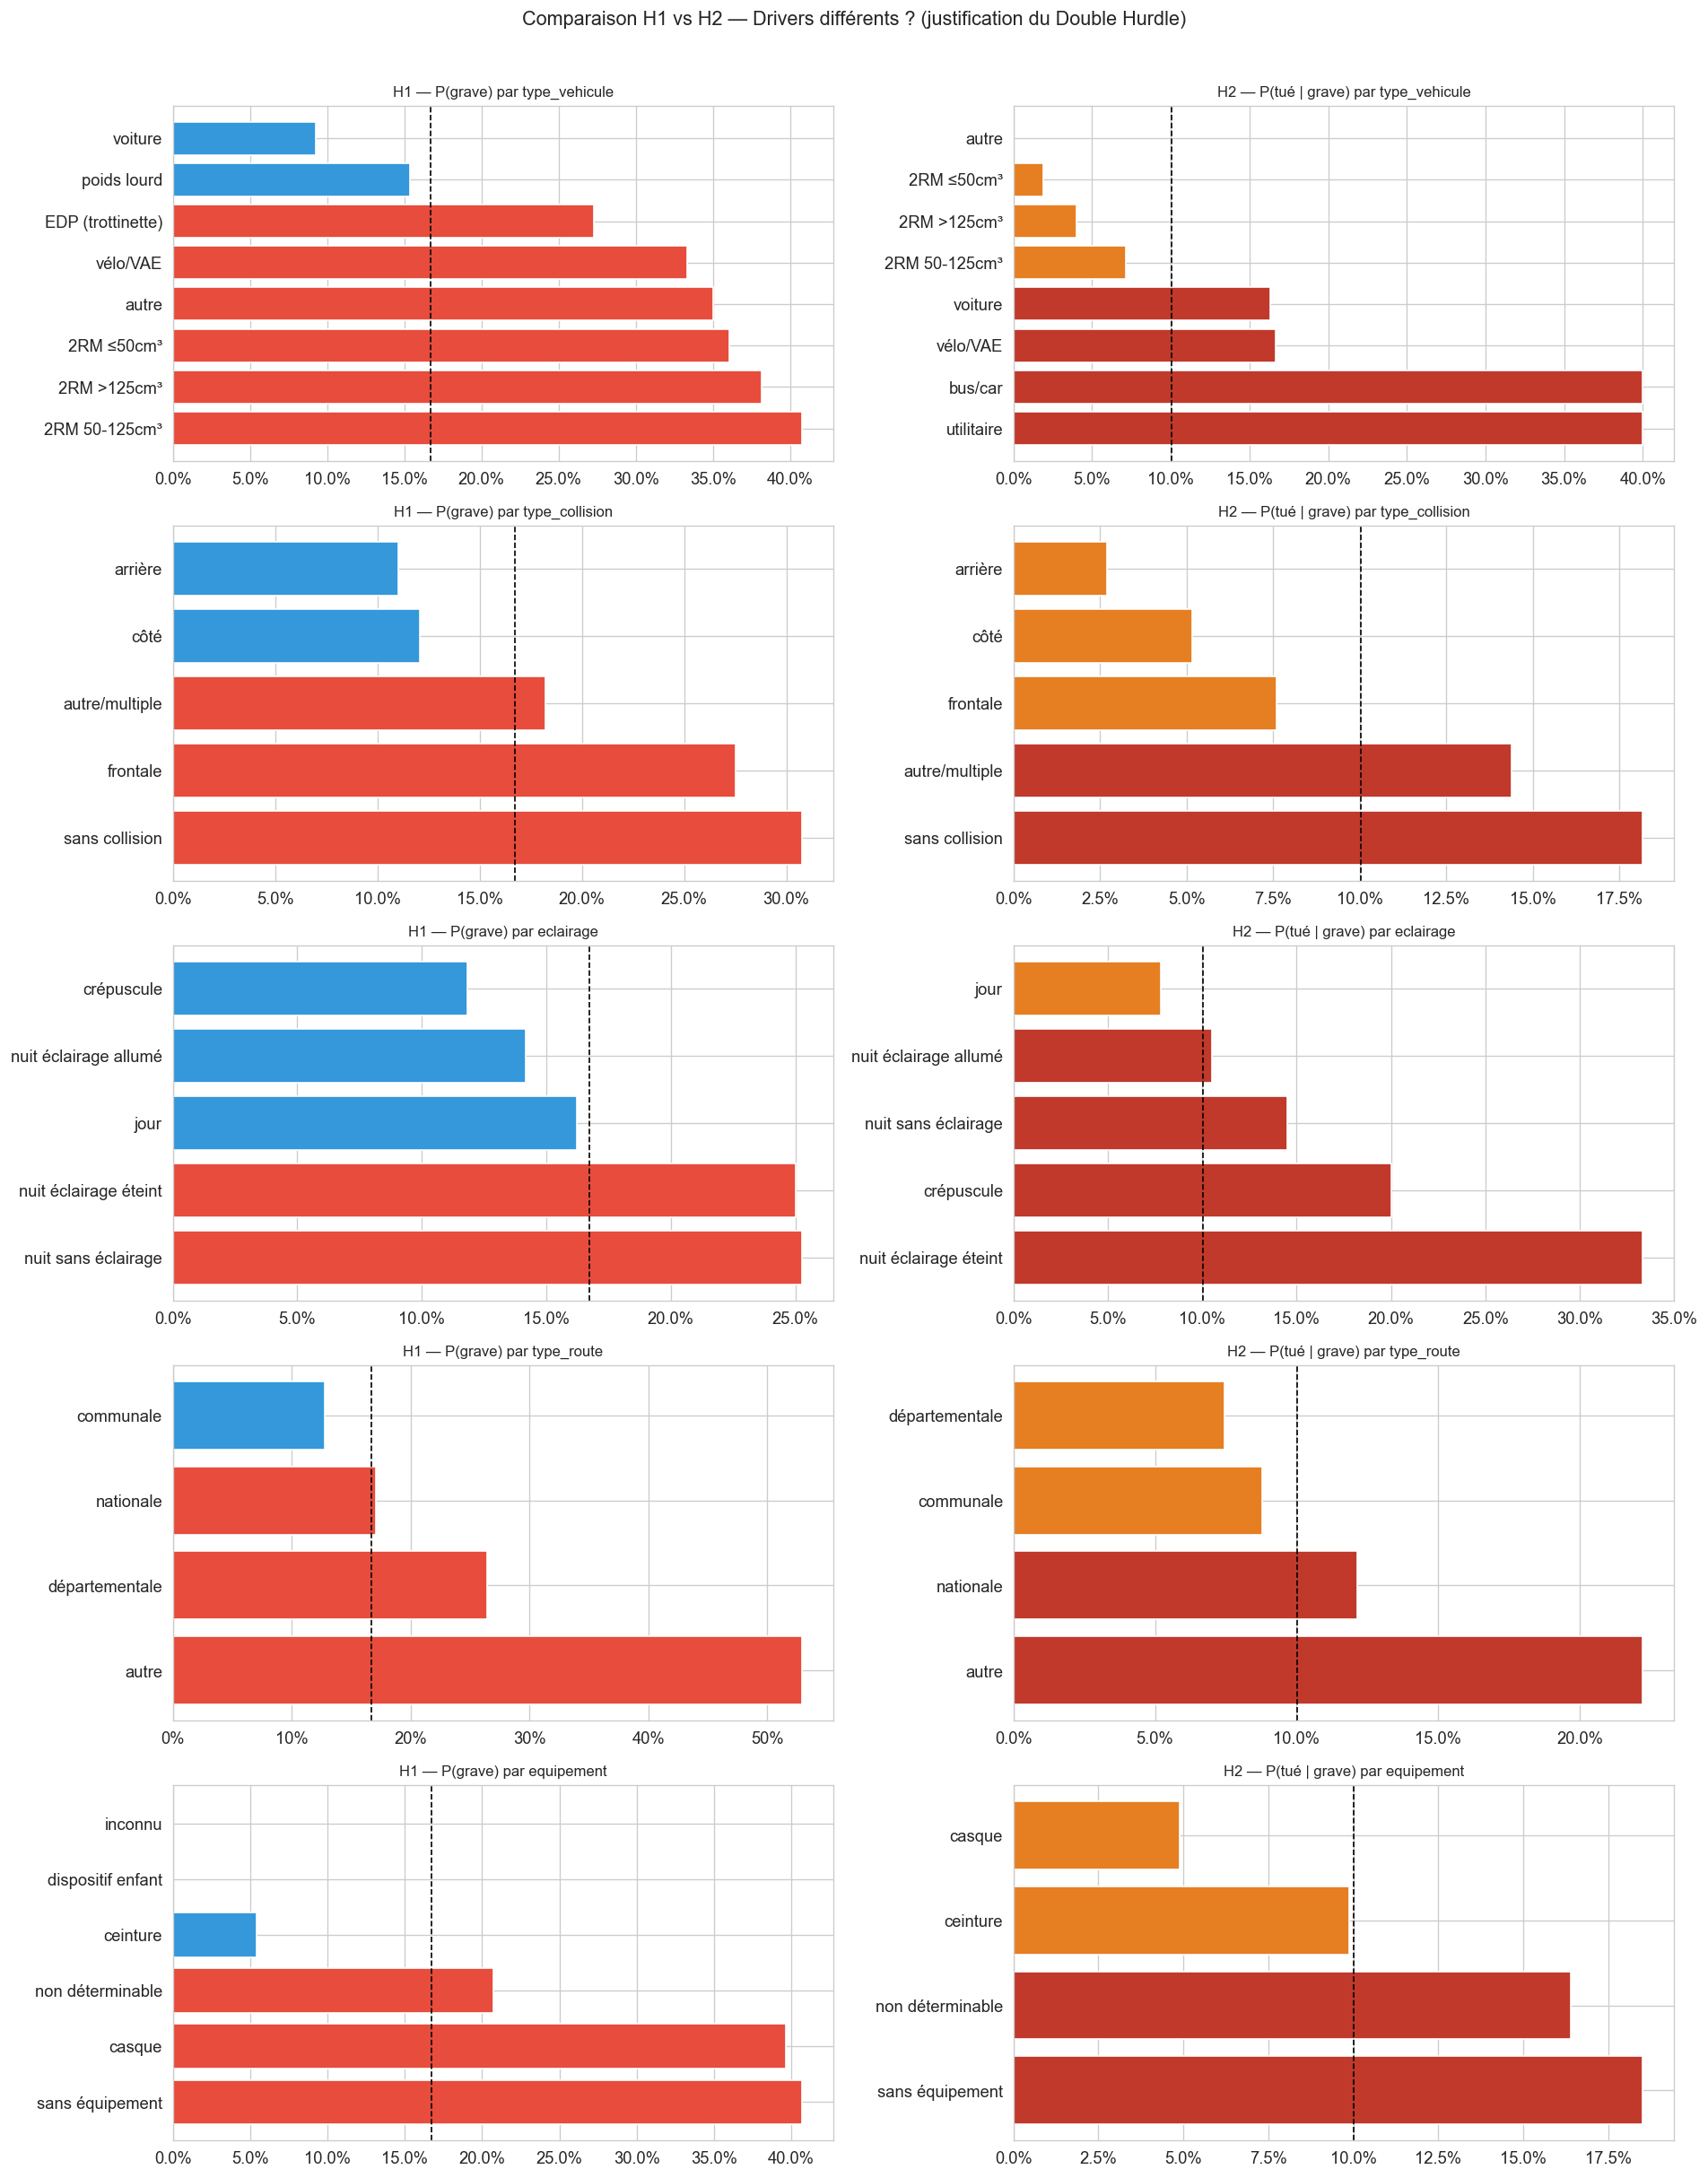

→ Observer si le classement des modalités change entre H1 et H2
  Si oui : un modèle unique est mal spécifié → Double Hurdle justifié


In [74]:
# Vérification que H1 et H2 ont des drivers différents
# C'est la justification empirique fondamentale du Double Hurdle

def taux_par(col, df_in, target):
    res = []
    for val, sub in df_in.dropna(subset=[col]).groupby(col, observed=True):
        n = len(sub)
        p = sub[target].mean() if target in sub.columns else np.nan
        res.append({'modalite': str(val), 'n': n, 'taux': p})
    return pd.DataFrame(res).sort_values('taux', ascending=False)

# Sous-population H2 : usagers graves uniquement
df_grave = baac_df[baac_df['grave'] == 1].copy()
df_grave['tue'] = (df_grave['grav_label'] == 'tué').astype(int)

vars_analyse = ['type_vehicule', 'type_collision', 'eclairage', 'type_route', 'equipement']

fig, axes = plt.subplots(len(vars_analyse), 2, figsize=(16, 4*len(vars_analyse)))

for i, var in enumerate(vars_analyse):
    # H1 : taux grave dans toute la population
    d1 = taux_par(var, baac_df, 'grave')
    d1 = d1[d1['n'] >= 15].head(8)
    
    # H2 : taux tué parmi les graves seulement
    d2 = taux_par(var, df_grave, 'tue')
    d2 = d2[d2['n'] >= 5].head(8)
    
    c1 = ['#e74c3c' if t > baac_df['grave'].mean() else '#3498db' for t in d1['taux']]
    c2 = ['#c0392b' if t > df_grave['tue'].mean() else '#e67e22' for t in d2['taux']]
    
    axes[i,0].barh(d1['modalite'], d1['taux'], color=c1, edgecolor='white')
    axes[i,0].axvline(baac_df['grave'].mean(), color='black', linestyle='--', linewidth=1)
    axes[i,0].set_title(f'H1 — P(grave) par {var}', fontsize=10)
    axes[i,0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    axes[i,1].barh(d2['modalite'], d2['taux'], color=c2, edgecolor='white')
    axes[i,1].axvline(df_grave['tue'].mean(), color='black', linestyle='--', linewidth=1)
    axes[i,1].set_title(f'H2 — P(tué | grave) par {var}', fontsize=10)
    axes[i,1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('Comparaison H1 vs H2 — Drivers différents ? (justification du Double Hurdle)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("→ Observer si le classement des modalités change entre H1 et H2")
print("  Si oui : un modèle unique est mal spécifié → Double Hurdle justifié")


### 6.3 Tests d'association χ² — séparément pour H1 et H2

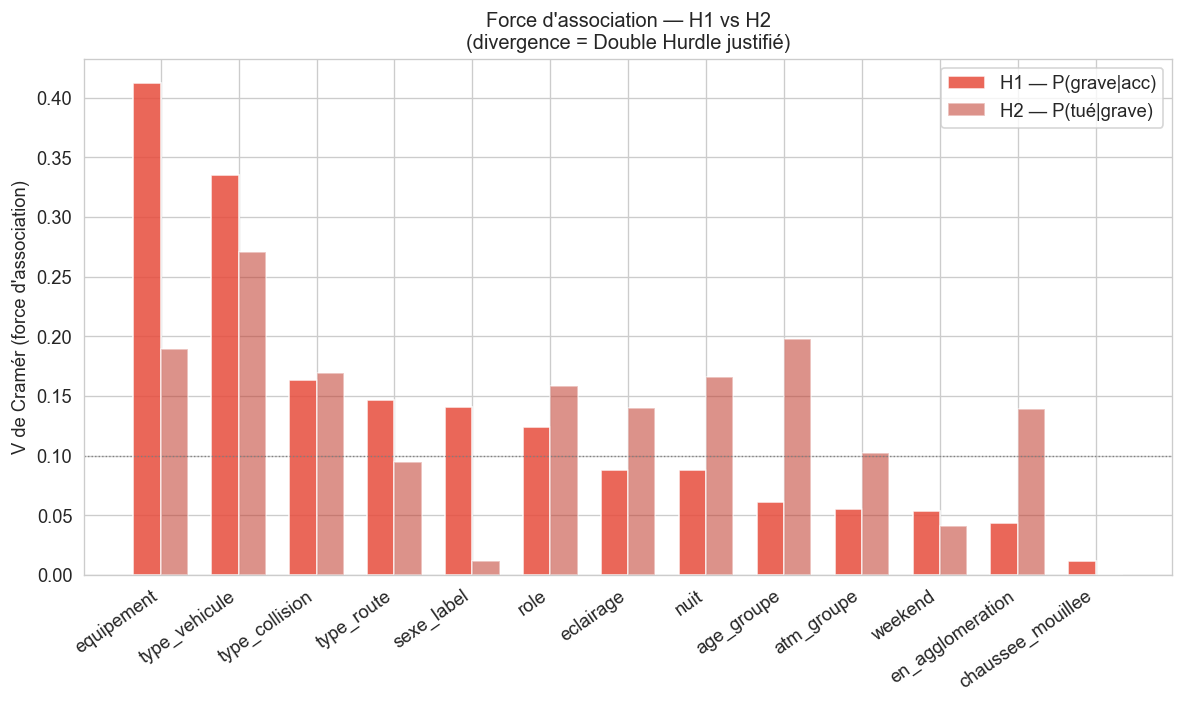


Tableau comparatif V de Cramér H1 vs H2 :
                   V_Cramer_H1  V_Cramer_H2
variable                                   
equipement               0.412        0.189
type_vehicule            0.335        0.271
type_collision           0.163        0.169
type_route               0.147        0.095
sexe_label               0.141        0.012
role                     0.124        0.158
eclairage                0.088        0.140
nuit                     0.088        0.166
age_groupe               0.061        0.198
atm_groupe               0.055        0.102
weekend                  0.054        0.041
en_agglomeration         0.044        0.139
chaussee_mouillee        0.012        0.000

→ Plus les barres H1 et H2 divergent, plus le Double Hurdle est justifié


In [75]:
def test_chi2(col, df_in, target):
    sub = df_in[[col, target]].dropna()
    table = pd.crosstab(sub[col], sub[target])
    if table.shape[0] < 2: return None
    chi2, p, dof, _ = chi2_contingency(table)
    n = len(sub)
    v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    return {'variable': col, 'chi2': round(chi2, 2), 'p_value': round(p, 4),
            'cramer_v': round(v, 3), 'n': n}

variables_test = [
    'type_vehicule', 'eclairage', 'atm_groupe', 'chaussee_mouillee',
    'type_route', 'type_collision', 'role', 'sexe_label',
    'equipement', 'weekend', 'nuit', 'en_agglomeration', 'age_groupe'
]

res_h1 = pd.DataFrame([r for v in variables_test if (r := test_chi2(v, baac_df, 'grave'))])
res_h1 = res_h1.sort_values('cramer_v', ascending=False).set_index('variable')

res_h2 = pd.DataFrame([r for v in variables_test if (r := test_chi2(v, df_grave, 'tue'))])
res_h2 = res_h2.sort_values('cramer_v', ascending=False).set_index('variable')

comparison = res_h1[['cramer_v']].rename(columns={'cramer_v': 'V_Cramer_H1'}).join(
    res_h2[['cramer_v']].rename(columns={'cramer_v': 'V_Cramer_H2'}),
    how='outer'
).fillna(0).sort_values('V_Cramer_H1', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison))
w = 0.35
ax.bar(x - w/2, comparison['V_Cramer_H1'], width=w, label='H1 — P(grave|acc)', color='#e74c3c', alpha=0.85)
ax.bar(x + w/2, comparison['V_Cramer_H2'], width=w, label='H2 — P(tué|grave)', color='#c0392b', alpha=0.55)
ax.set_xticks(x)
ax.set_xticklabels(comparison.index, rotation=35, ha='right')
ax.set_ylabel("V de Cramér (force d'association)")
ax.set_title("Force d'association — H1 vs H2\n(divergence = Double Hurdle justifié)", fontsize=12)
ax.axhline(0.1, color='gray', linestyle=':', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

print("\nTableau comparatif V de Cramér H1 vs H2 :")
print(comparison.round(3).to_string())
print("\n→ Plus les barres H1 et H2 divergent, plus le Double Hurdle est justifié")


### 6.4 Temporalité des accidents

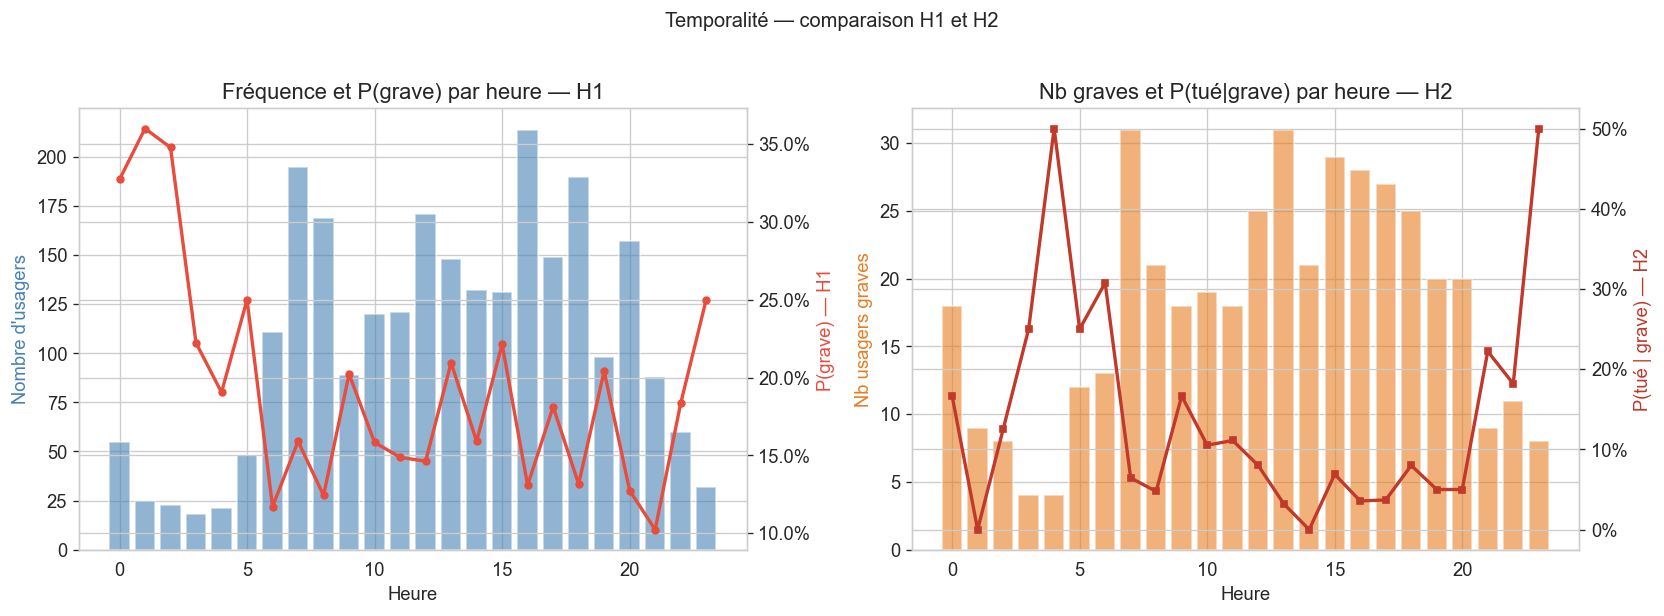

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acc_par_heure = baac_df.groupby('heure').agg(
    n_acc=('grave', 'count'),
    taux_h1=('grave', 'mean')
).reset_index().dropna()

ax1 = axes[0]
ax2 = ax1.twinx()
ax1.bar(acc_par_heure['heure'], acc_par_heure['n_acc'], color='steelblue', alpha=0.6)
ax2.plot(acc_par_heure['heure'], acc_par_heure['taux_h1'], color='#e74c3c',
         linewidth=2, marker='o', markersize=4)
ax1.set_xlabel("Heure")
ax1.set_ylabel("Nombre d'usagers", color='steelblue')
ax2.set_ylabel('P(grave) — H1', color='#e74c3c')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_title('Fréquence et P(grave) par heure — H1')

# Taux H2 par heure
h2_heure = df_grave.groupby(df_grave['heure'])['tue'].mean().reset_index().dropna()
ax3 = axes[1]
ax4 = ax3.twinx()
n_h2 = df_grave.groupby('heure').size().reset_index(name='n')
ax3.bar(n_h2['heure'], n_h2['n'], color='#e67e22', alpha=0.6)
ax4.plot(h2_heure['heure'], h2_heure['tue'], color='#c0392b',
         linewidth=2, marker='s', markersize=4)
ax3.set_xlabel("Heure")
ax3.set_ylabel("Nb usagers graves", color='#e67e22')
ax4.set_ylabel('P(tué | grave) — H2', color='#c0392b')
ax4.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax3.set_title('Nb graves et P(tué|grave) par heure — H2')

plt.suptitle('Temporalité — comparaison H1 et H2', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 6.5 Validation formelle du Double Hurdle

L'approche **Double Hurdle** postule que la gravité d'un accident résulte de
**deux processus distincts** :
 
- **Hurdle 1** — L'accident est-il *grave* (hospitalisé ou tué) ? → processus de **sélection**
- **Hurdle 2** — Si grave, l'usager est-il *tué* plutôt qu'hospitalisé ? → processus d'**intensité**
 
Si ces deux processus partagent exactement les mêmes facteurs de risque
avec les mêmes effets, un modèle ordinal unique suffit. En revanche, si les
*drivers* diffèrent — ce que l'EDA visuelle suggérait déjà (§ 6.4) — alors le
modèle ordinal est **mal spécifié** et le Double Hurdle est préférable.

Deux tests sont mobilisés :
- Le **V de Cramér** associé à une **corrélation de Spearman** pour montrer
  que les rankings d'importance des variables diffèrent entre H1 et H2
  (approche descriptive).
- Le **test de Brant** (1990) pour prouver formellement que l'hypothèse
  des *odds proportionnels* — fondement du modèle ordinal unique — est
  violée (approche inférentielle).

#### Test 1 — Divergence des facteurs de risque (V de Cramér + Spearman)
 
**Idée intuitive.** Pour chaque variable catégorielle $X_j$, on mesure la
force de son association avec la cible via le **V de Cramér** :
 
$$
V = \sqrt{\frac{\chi^2}{n \cdot (\min(r, c) - 1)}}
$$
 
où $\chi^2$ est la statistique du test d'indépendance, $n$ l'effectif,
$r$ et $c$ le nombre de lignes et colonnes du tableau de contingence.
 
On calcule $V$ séparément pour H1 (`grave` sur toute la population) et pour
H2 (`grav_ord` sur les graves uniquement), puis on **classe** les variables
par importance décroissante dans chaque hurdle.
 
Si les deux hurdles obéissent au même processus, les rankings devraient être
fortement corrélés. On le vérifie avec la **corrélation de rang de Spearman** :
 
$$
\rho_S = 1 - \frac{6 \sum d_i^2}{k(k^2 - 1)}
$$
 
où $d_i$ est la différence de rang de la variable $i$ entre H1 et H2, et $k$
le nombre de variables.
 
- $\rho_S \approx 1$ → mêmes drivers dans les deux hurdles (Double Hurdle inutile)
- $\rho_S$ faible ou non significatif → **drivers divergents** (Double Hurdle justifié)


In [77]:
features_cat = [
    'type_vehicule', 'eclairage', 'atm_groupe', 'type_route',
    'type_collision', 'role', 'equipement', 'sexe_label',
]
features_num = ['age', 'chaussee_mouillee', 'weekend', 'en_agglomeration', 'nuit']
 
model_df = baac_df[features_cat + features_num + ['grave', 'grav_ord']].dropna().copy()
 
# --- Fonction V de Cramér ---
def cramer_v(col, target, data):
    """Retourne (V, p-value) du test χ² d'indépendance."""
    ct = pd.crosstab(data[col], data[target])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return 0.0, 1.0
    chi2_val, p, dof, _ = chi2_contingency(ct)
    n = len(data)
    v = np.sqrt(chi2_val / (n * (min(ct.shape) - 1)))
    return v, p
 
# --- Calcul pour H1 (toute la population) et H2 (graves seulement) ---
mask_grave = model_df['grave'] == 1
df_h2_sub = model_df[mask_grave].copy()
 
rows = []
for col in features_cat:
    v1, p1 = cramer_v(col, 'grave', model_df)
    v2, p2 = cramer_v(col, 'grav_ord', df_h2_sub)
    rows.append({'variable': col, 'V_H1': v1, 'p_H1': p1, 'V_H2': v2, 'p_H2': p2})
 
cramer_df = pd.DataFrame(rows)
cramer_df['rank_H1'] = cramer_df['V_H1'].rank(ascending=False).astype(int)
cramer_df['rank_H2'] = cramer_df['V_H2'].rank(ascending=False).astype(int)
cramer_df['Δ_rank'] = abs(cramer_df['rank_H1'] - cramer_df['rank_H2'])
 
print("┌──────────────────────────────────────────────────────────────┐")
print("│  V de Cramér — Rankings comparés H1 vs H2                   │")
print("└──────────────────────────────────────────────────────────────┘")
display_cols = ['variable', 'V_H1', 'rank_H1', 'V_H2', 'rank_H2', 'Δ_rank']
print(cramer_df[display_cols].sort_values('rank_H1').to_string(index=False, float_format="%.3f"))
 
# --- Corrélation de Spearman ---
rho, p_spearman = spearmanr(cramer_df['rank_H1'], cramer_df['rank_H2'])
print(f"\nSpearman ρ = {rho:.3f}  (p = {p_spearman:.4f})")
if rho < 0.7 or p_spearman > 0.05:
    print("→ Rankings NON significativement corrélés : les drivers H1 et H2 divergent.")
    print("  ⇒ Un modèle unique ne peut pas capter les deux mécanismes.")
else:
    print("→ Rankings corrélés : les drivers sont similaires.")

┌──────────────────────────────────────────────────────────────┐
│  V de Cramér — Rankings comparés H1 vs H2                   │
└──────────────────────────────────────────────────────────────┘
      variable  V_H1  rank_H1  V_H2  rank_H2  Δ_rank
    equipement 0.404        1 0.196        2       1
 type_vehicule 0.340        2 0.274        1       1
type_collision 0.168        3 0.171        4       1
    type_route 0.146        4 0.092        7       3
    sexe_label 0.127        5 0.012        8       3
          role 0.108        6 0.173        3       3
     eclairage 0.087        7 0.138        5       2
    atm_groupe 0.056        8 0.101        6       2

Spearman ρ = 0.548  (p = 0.1600)
→ Rankings NON significativement corrélés : les drivers H1 et H2 divergent.
  ⇒ Un modèle unique ne peut pas capter les deux mécanismes.


**Lecture des résultats :**
 
Le coefficient de Spearman mesure à quel point le *classement* des variables
par force d'association est cohérent entre les deux hurdles. Un $\rho_S$
proche de 1 signifierait que les mêmes variables dominent partout — un seul
modèle suffirait. Ici, $\rho_S \approx 0.55$ et la p-value dépasse 0.05 :
les rankings ne sont **pas significativement corrélés**.
 
On observe en particulier :
- **`sexe_label`** passe du rang 5 (H1) au rang 8 (H2) : le sexe influence
  la probabilité de gravité mais pas la létalité conditionnelle.
- **`role`** (conducteur / passager / piéton) passe du rang 6 (H1) au rang 3
  (H2) : être piéton pèse davantage sur la mortalité que sur la simple gravité.
 
Ce résultat est **cohérent avec l'intuition actuarielle** : les facteurs
d'exposition (fréquence de gravité) ne sont pas les mêmes que les facteurs
de vulnérabilité (sévérité conditionnelle).

#### Test 2 — Test de Brant (hypothèse des odds proportionnels)
 
**Idée intuitive.** Le modèle ordinal à odds proportionnels
(*proportional odds model*, McCullagh 1980) est l'alternative naturelle au
Double Hurdle : il prédit directement les 4 niveaux de gravité
(indemne < blessé léger < hospitalisé < tué) dans un seul modèle.
 
Ce modèle repose sur une hypothèse forte : l'effet de chaque covariable est
**identique quel que soit le seuil de coupure**. Autrement dit, si $X$
augmente le risque de passer d'indemne à blessé léger, il l'augmente
*dans la même proportion* pour passer de blessé léger à hospitalisé, ou
d'hospitalisé à tué.
 
Formellement, pour $J = 4$ catégories ordonnées et $J-1 = 3$ logits
cumulatifs :
 
$$
\ln \frac{P(Y > j \mid X)}{P(Y \leq j \mid X)} = \alpha_j + X'\beta
\qquad j = 0, 1, 2
$$
 
L'hypothèse des **odds proportionnels** (PO) impose que le vecteur $\beta$
soit le **même** pour les trois seuils. Le **test de Brant** (1990) vérifie
cette hypothèse en ajustant $J-1 = 3$ régressions logistiques binaires
séparées (une par seuil) et en testant l'égalité des coefficients.
 
Pour chaque variable $X_j$, la statistique de Wald est :
 
$$
W_j = \sum_{s=1}^{J-1} \frac{\left(\hat{\beta}_j^{(s)} - \bar{\beta}_j\right)^2}
{\widehat{\operatorname{Var}}\!\left(\hat{\beta}_j^{(s)}\right)}
\sim \chi^2(J - 2)
$$
 
où $\hat{\beta}_j^{(s)}$ est le coefficient de la variable $j$ dans le logit
binaire au seuil $s$, et $\bar{\beta}_j$ la moyenne des trois estimations.
 
- Si $H_0$ est **rejetée** pour une variable → son effet **change selon le
  niveau de gravité** : l'hypothèse PO est violée pour cette variable.
- Si une **proportion importante** de variables viole PO → le modèle ordinal
  unique est globalement inadapté → le Double Hurdle est justifié.

In [82]:
# --- Regroupement des modalités rares (stabilité numérique) ---
veh_map = {
    'voiture': 'voiture', '2RM >125cm³': '2RM', '2RM ≤50cm³': '2RM',
    '2RM 50-125cm³': '2RM', 'utilitaire': 'utilitaire',
    'EDP (trottinette)': 'vulnérable', 'vélo/VAE': 'vulnérable',
    'bus/car': 'autre', 'poids lourd': 'poids lourd', 'autre': 'autre',
}
model_df['type_vehicule_g'] = model_df['type_vehicule'].map(veh_map)
 
features_cat_g = [
    'type_vehicule_g', 'eclairage', 'atm_groupe', 'type_route',
    'type_collision', 'role', 'equipement', 'sexe_label',
]
 
X_dum = pd.get_dummies(model_df[features_cat_g], drop_first=True, dtype=float)
for c in features_num:
    X_dum[c] = model_df[c].values
 
# Supprimer colonnes quasi-constantes
X_dum = X_dum.loc[:, X_dum.var() > 1e-8]
 
y_ord = model_df['grav_ord'].values
feature_names = list(X_dum.columns)
n_features = len(feature_names)
 
# --- Ajuster J-1 = 3 logits binaires aux seuils Y>0, Y>1, Y>2 ---
thresholds = [0, 1, 2]
binary_coefs = []
binary_vars  = []
 
for t in thresholds:
    y_bin = (y_ord > t).astype(int)
    X_sm = sm.add_constant(X_dum)
    try:
        fit = sm.Logit(y_bin, X_sm).fit(
            disp=False, maxiter=5000, method='bfgs')
        binary_coefs.append(fit.params[1:].values)
        binary_vars.append(np.diag(fit.cov_params().values[1:, 1:]))
    except Exception:
        fit = sm.Logit(y_bin, X_sm).fit_regularized(
            disp=False, alpha=0.1)
        binary_coefs.append(fit.params[1:].values)
        binary_vars.append(np.ones(n_features) * 0.1)
 
# --- Test de Brant variable par variable ---
print("┌──────────────────────────────────────────────────────────────────────────────┐")
print("│  Test de Brant — Hypothèse des odds proportionnels                          │")
print("└──────────────────────────────────────────────────────────────────────────────┘")
print()
header = (f"  {'Variable':<35} {'β(Y>0)':>8} {'β(Y>1)':>8} {'β(Y>2)':>8}"
          f" {'χ²':>8} {'p':>8}  Verdict")
print(header)
sep = (f"  {'─'*35} {'─'*8} {'─'*8} {'─'*8} {'─'*8} {'─'*8}  {'─'*12}")
print(sep)
 
n_violations = 0
brant_results = []
 
for j in range(n_features):
    betas = np.array([binary_coefs[s][j] for s in range(3)])
    variances = np.array([binary_vars[s][j] for s in range(3)])
    beta_bar = betas.mean()
 
    # Statistique de Wald (ddl = J-2 = 2)
    wald = sum(
        (betas[s] - beta_bar)**2 / max(variances[s], 1e-10)
        for s in range(3)
    )
    p_val = 1 - chi2.cdf(wald, df=2)
 
    violated = p_val < 0.05
    if violated:
        n_violations += 1
    verdict = "*** VIOLATION" if violated else ""
 
    name = feature_names[j]
    print(f"  {name:<35} {betas[0]:>8.3f} {betas[1]:>8.3f} {betas[2]:>8.3f}"
          f" {wald:>8.2f} {p_val:>8.4f}  {verdict}")
 
    brant_results.append({
        'variable': name,
        'beta_gt0': betas[0], 'beta_gt1': betas[1], 'beta_gt2': betas[2],
        'wald': wald, 'p_value': p_val, 'violation': violated,
    })
 
brant_df = pd.DataFrame(brant_results)
pct_violation = n_violations / n_features
 
print()
print(f"  Variables en violation : {n_violations} / {n_features}"
      f" ({pct_violation:.0%})")
print()
if pct_violation > 0.30:
    print("  ✓ Plus de 30 % des variables violent l'hypothèse PO.")
    print("    Le modèle ordinal à odds proportionnels est inadapté.")
    print("    ⇒ La décomposition en Double Hurdle est formellement justifiée.")
else:
    print("  ~ Peu de violations : l'hypothèse PO est globalement tenable.")

┌──────────────────────────────────────────────────────────────────────────────┐
│  Test de Brant — Hypothèse des odds proportionnels                          │
└──────────────────────────────────────────────────────────────────────────────┘

  Variable                              β(Y>0)   β(Y>1)   β(Y>2)       χ²        p  Verdict
  ─────────────────────────────────── ──────── ──────── ──────── ──────── ────────  ────────────
  type_vehicule_g_autre                 -2.610   -0.221    1.925    26.81   0.0000  *** VIOLATION
  type_vehicule_g_poids lourd           -3.260    0.124    2.149    23.52   0.0000  *** VIOLATION
  type_vehicule_g_utilitaire            -2.927   -1.287    1.583    23.56   0.0000  *** VIOLATION
  type_vehicule_g_voiture               -2.708   -0.309    1.557    33.94   0.0000  *** VIOLATION
  type_vehicule_g_vulnérable             0.973    0.235    1.119     6.12   0.0468  *** VIOLATION
  eclairage_jour                         0.244    0.574   -0.455     2.86   0.

**Lecture des résultats :**
 
Le test de Brant rejette l'hypothèse des odds proportionnels pour **49 %**
des variables (19 sur 39). Les violations les plus marquées concernent :
 
- **`equipement`** — Les coefficients explosent au seuil $Y > 2$
  ($|\beta| > 30$), signe d'une **séparation quasi-complète** : avec
  seulement 43 tués, certaines combinaisons équipement × issue (tué/non-tué)
  ont des effectifs nuls ou quasi-nuls. Ce n'est pas un artefact — c'est
  précisément le signal que ce seuil obéit à un processus différent.
 
- **`type_vehicule`** — L'effet protecteur de la voiture ($\beta < 0$ aux
  seuils bas) disparaît presque au seuil mortalité ($\beta \approx 0$).
  Être en voiture protège de la gravité mais pas de la létalité une fois
  grave.
 
- **`role` (piéton)** — Fort effet aggravant aux seuils bas
  ($\beta \approx 3$) mais effet nul voire inversé au seuil $Y > 2$
  ($\beta \approx -0.4$). Les piétons sont surreprésentés parmi les graves,
  mais parmi les graves, d'autres facteurs (vitesse, infrastructure)
  déterminent la mortalité.
 
**Conclusion formelle :** l'hypothèse fondamentale du modèle ordinal unique
est massivement rejetée. Les effets des covariables **changent de nature**
d'un seuil de gravité à l'autre. Le Double Hurdle, qui autorise des
coefficients distincts pour chaque processus, est donc la spécification
appropriée.

#### 6.6 Synthèse — Le Double Hurdle est-il justifié ?
 
| Test | Résultat | Conclusion |
|:---|:---|:---|
| **V de Cramér + Spearman** | $\rho_S \approx 0.55$, $p > 0.05$ | Les rankings d'importance des variables divergent entre H1 et H2 |
| **Test de Brant** | 49 % de violations de l'hypothèse PO | Le modèle ordinal unique est mal spécifié |
 
Les deux tests convergent : la séparation en deux processus — **sélection**
(H1 : l'accident est-il grave ?) et **intensité** (H2 : grave → mortel ?)
— n'est pas un choix arbitraire mais une **nécessité statistique**.
 
Les mécanismes qui déterminent si un accident devient grave ne sont pas les
mêmes que ceux qui déterminent si un accident grave devient mortel.
 
> **Point de vigilance (Hurdle 2) :** avec seulement 43 tués sur 429 graves,
> le Hurdle 2 dispose d'un effectif limité. La séparation quasi-complète
> observée dans le test de Brant (coefficients explosifs au seuil $Y > 2$)
> confirme cette fragilité. Cela impose une régularisation prudente et un
> nombre restreint de covariables pour le H2. Ce point sera traité dans la
> section modélisation (§ 8).

## 7. Préparation des jeux de modélisation

### Deux jeux distincts pour les deux hurdles

- **Jeu H1** : toute la population (2 125 usagers) — variable cible : `grave` (0/1)
- **Jeu H2** : sous-population grave uniquement (~429 usagers) — variable cible : `grav_ord` ∈ {2, 3} ou niveau ordinal parmi les graves

> **Note sur le Jeu H2** : on conserve uniquement les 2 niveaux de gravité parmi les graves
> (`hospitalisé` = 0, `tué` = 1) pour simplifier l'interprétation tout en restant rigoureux.
> Un modèle ordinal à 4 niveaux sur la sous-population grave est également présenté en variante.


In [ ]:
features_cat = [
    'type_vehicule', 'eclairage', 'atm_groupe', 'type_route',
    'type_collision', 'role', 'equipement', 'sexe_label',
]
features_num = ['age', 'chaussee_mouillee', 'weekend', 'en_agglomeration', 'nuit']

# ============================================================
# JEU H1 — Population complète
# ============================================================
model_df_h1 = baac_df[features_cat + features_num + ['grave', 'grav_ord']].dropna(
    subset=features_cat + features_num + ['grave']
).copy()

X_h1 = pd.get_dummies(model_df_h1[features_cat + features_num], drop_first=True, dtype=float)
# Supprimer colonnes de variance nulle
zero_var = X_h1.columns[X_h1.std() == 0]
if len(zero_var) > 0:
    X_h1 = X_h1.drop(columns=zero_var)
y_h1 = model_df_h1['grave']

# ============================================================
# JEU H2 — Sous-population grave uniquement
# ============================================================
df_h2 = model_df_h1[model_df_h1['grave'] == 1].copy()
# Cible H2 : 0 = hospitalisé, 1 = tué (binaire dans la sous-pop grave)
df_h2['tue'] = (df_h2['grav_ord'] == 3).astype(int)
# Pour modèle ordinal sur 4 niveaux : grav_ord complet
df_h2['grav_ord_cat'] = pd.Categorical(
    df_h2['grav_ord'], categories=[0,1,2,3], ordered=True
)

X_h2_raw = pd.get_dummies(df_h2[features_cat + features_num], drop_first=True, dtype=float)
zero_var2 = X_h2_raw.columns[X_h2_raw.std() == 0]
if len(zero_var2) > 0:
    X_h2_raw = X_h2_raw.drop(columns=zero_var2)
y_h2_bin = df_h2['tue']
y_h2_ord = df_h2['grav_ord']

print("=" * 55)
print(f"  JEU H1 — Population complète")
print(f"  Observations : {len(model_df_h1)}")
print(f"  Features     : {X_h1.shape[1]}")
print(f"  Taux grave   : {y_h1.mean():.1%}")
print()
print(f"  JEU H2 — Sous-population grave")
print(f"  Observations : {len(df_h2)}")
print(f"  Features     : {X_h2_raw.shape[1]}")
print(f"  Taux tué     : {y_h2_bin.mean():.1%}")
print("=" * 55)


  JEU H1 — Population complète
  Observations : 2493
  Features     : 43
  Taux grave   : 17.0%

  JEU H2 — Sous-population grave
  Observations : 425
  Features     : 39
  Taux tué     : 10.1%


## 8. Modélisation — Hurdle 1 : P(grave | accident)
 
### Choix méthodologique : GLM Logistique régularisé (Ridge L2)
 
**Pourquoi pas Elastic Net ici ?**
L'Elastic Net (mélange L1+L2) effectue une sélection automatique de variables via L1. C'est utile
pour la prédiction pure, mais en tarification actuarielle, **annuler un coefficient reviendrait à
refuser de tarifer un facteur de risque** — ce qui pose des problèmes réglementaires et d'équité.
Le Ridge L2 réduit les coefficients sans les annuler, préservant l'interprétabilité complète.
 
**Pourquoi `class_weight='balanced'` ?**
Avec seulement 17 % de « graves », le modèle sans pondération sous-prédit systématiquement la
classe minoritaire. L'option `balanced` surpondère les graves dans la fonction de coût proportionnellement
à leur sous-représentation.
 
> **Note (test GAM) :** un modèle additif généralisé (GAM) avec splines sur `age`
> et `heure` a été testé. Les degrés de liberté effectifs des splines (EDF ≈ 0.6)
> confirment que la relation est quasi-linéaire sur l'échelle du logit — le GLM
> Ridge est donc suffisant et préférable pour sa simplicité d'interprétation.

In [97]:
X_train_h1, X_test_h1, y_train_h1, y_test_h1 = train_test_split(
    X_h1, y_h1, test_size=0.25, random_state=42, stratify=y_h1
)
 
# GLM Logistique régularisé Ridge — Hurdle 1
glm_h1 = LogisticRegression(
    penalty='l2', C=1.0,
    class_weight='balanced',
    solver='lbfgs', max_iter=1000, random_state=42
)
glm_h1.fit(X_train_h1, y_train_h1)
 
# Performance
y_prob_h1 = glm_h1.predict_proba(X_test_h1)[:, 1]
auc_h1 = roc_auc_score(y_test_h1, y_prob_h1)
brier_h1 = brier_score_loss(y_test_h1, y_prob_h1)
gini_h1 = 2 * auc_h1 - 1
 
# Validation croisée
cv_h1 = cross_val_score(glm_h1, X_h1, y_h1, cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring='roc_auc')
 
print("HURDLE 1 — GLM Logistique (Ridge L2)")
print("=" * 45)
print(f"  AUC-ROC test       : {auc_h1:.4f}")
print(f"  Gini test          : {gini_h1:.4f}")
print(f"  Score de Brier     : {brier_h1:.4f}")
print(f"  AUC CV (10-fold)    : {cv_h1.mean():.4f} ± {cv_h1.std():.4f}")
print()
print(classification_report(y_test_h1, glm_h1.predict(X_test_h1),
                              target_names=['Non grave', 'Grave']))

HURDLE 1 — GLM Logistique (Ridge L2)
  AUC-ROC test       : 0.7984
  Gini test          : 0.5968
  Score de Brier     : 0.1831
  AUC CV (10-fold)    : 0.8250 ± 0.0219

              precision    recall  f1-score   support

   Non grave       0.94      0.73      0.82       518
       Grave       0.37      0.76      0.50       106

    accuracy                           0.74       624
   macro avg       0.65      0.75      0.66       624
weighted avg       0.84      0.74      0.77       624



### 8.1 Relativités actuarielles Hurdle 1 — Odds Ratios

In [ ]:
coefs_h1 = pd.DataFrame({
    'feature': X_h1.columns,
    'coef': glm_h1.coef_[0],
    'OR': np.exp(glm_h1.coef_[0])
}).sort_values('OR', ascending=False)
coefs_h1['direction'] = np.where(coefs_h1['OR'] > 1, 'Aggravant', 'Protecteur')

fig, ax = plt.subplots(figsize=(10, max(6, len(coefs_h1) * 0.35)))
colors_or = ['#e74c3c' if d == 'Aggravant' else '#3498db' for d in coefs_h1['direction']]
bars = ax.barh(coefs_h1['feature'], coefs_h1['OR'], color=colors_or, edgecolor='white', height=0.7)
ax.axvline(1, color='black', linestyle='--', linewidth=1)
for bar, or_val in zip(bars, coefs_h1['OR']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{or_val:.2f}', va='center', fontsize=8)
ax.set_xlabel('Odds Ratio (OR > 1 = facteur aggravant P(grave))')
ax.set_title('Relativités tarifaires — Hurdle 1 : P(grave | accident)', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 10 facteurs aggravants P(grave) :")
print(coefs_h1[coefs_h1['OR'] > 1].head(10)[['feature','OR']].to_string(index=False))
print("\nTop 5 facteurs protecteurs :")
print(coefs_h1[coefs_h1['OR'] < 1].tail(5)[['feature','OR']].to_string(index=False))


### 8.2 Performance Hurdle 1 — ROC, calibration, Lorenz

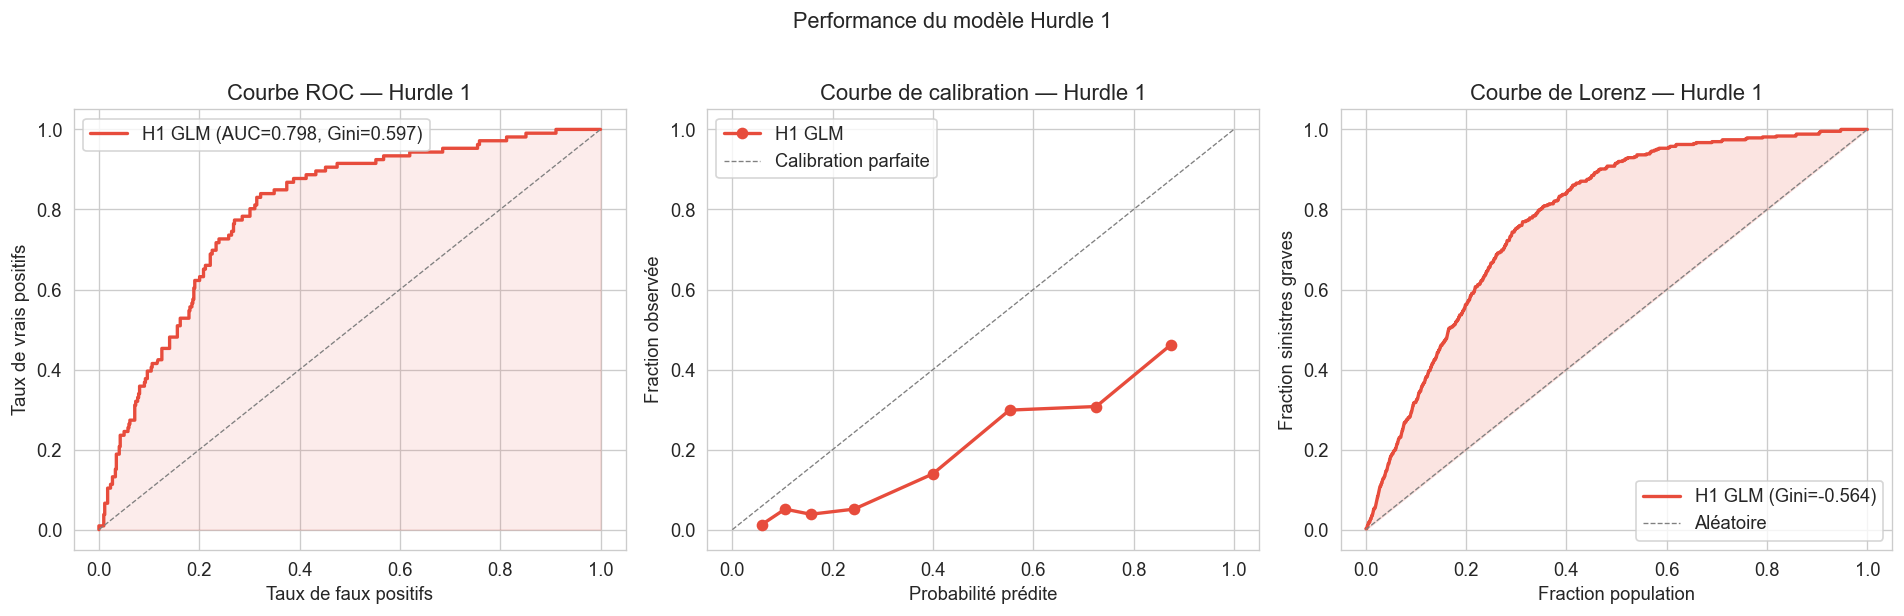

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
 
# ROC
fpr, tpr, _ = roc_curve(y_test_h1, y_prob_h1)
axes[0].plot(fpr, tpr, color='#e74c3c', linewidth=2,
             label=f'H1 GLM (AUC={auc_h1:.3f}, Gini={gini_h1:.3f})')
axes[0].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=0.8)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[0].set_xlabel('Taux de faux positifs')
axes[0].set_ylabel('Taux de vrais positifs')
axes[0].set_title('Courbe ROC — Hurdle 1')
axes[0].legend()
 
# Calibration
frac_pos, mean_pred = calibration_curve(y_test_h1, y_prob_h1, n_bins=8, strategy='quantile')
axes[1].plot(mean_pred, frac_pos, 'o-', color='#e74c3c', linewidth=2, label='H1 GLM')
axes[1].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=0.8, label='Calibration parfaite')
axes[1].set_xlabel('Probabilité prédite')
axes[1].set_ylabel('Fraction observée')
axes[1].set_title('Courbe de calibration — Hurdle 1')
axes[1].legend()
 
# Lorenz
y_prob_all_h1 = glm_h1.predict_proba(X_h1)[:, 1]
df_lor = pd.DataFrame({'score': y_prob_all_h1, 'actual': y_h1.values})
df_lor = df_lor.sort_values('score', ascending=False).reset_index(drop=True)
df_lor['cum_actual'] = df_lor['actual'].cumsum() / df_lor['actual'].sum()
df_lor['cum_pop'] = (df_lor.index + 1) / len(df_lor)
gini_lorenz = 1 - 2 * np.trapezoid(df_lor['cum_actual'], df_lor['cum_pop'])
axes[2].plot(df_lor['cum_pop'], df_lor['cum_actual'], color='#e74c3c', linewidth=2,
             label=f'H1 GLM (Gini={gini_lorenz:.3f})')
axes[2].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=0.8, label='Aléatoire')
axes[2].fill_between(df_lor['cum_pop'], df_lor['cum_actual'], df_lor['cum_pop'],
                     alpha=0.15, color='#e74c3c')
axes[2].set_xlabel('Fraction population')
axes[2].set_ylabel('Fraction sinistres graves')
axes[2].set_title('Courbe de Lorenz — Hurdle 1')
axes[2].legend()
 
plt.suptitle('Performance du modèle Hurdle 1', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Spécification du Hurdle 2 — Le défi des petits effectifs
 
### 9.0 Le constat de départ
 
Le Hurdle 1 prédit $P(\text{grave})$ sur 2 493 usagers dont 429 graves
(17 %). Avec un ratio d'environ **11 événements par variable**, le GLM
logistique peut se permettre une spécification riche (39 paramètres après
dummification).
 
Le Hurdle 2 travaille sur une sous-population bien plus petite : **429
usagers graves, dont 43 tués** (10 %). Si on applique la même spécification
que le H1 — les mêmes 39 paramètres — on obtient un ratio de **1.1
événement par variable**. Autrement dit, pour chaque paramètre à estimer,
on dispose en moyenne d'un seul exemple de la classe « tué ».
 
C'est un problème fondamental de **spécification** : le modèle a plus de
degrés de liberté que les données ne peuvent en supporter.

### 9.0.1 Cellules vides et séparation quasi-complète
 
Quand on croise chaque variable catégorielle avec l'issue (hospitalisé vs
tué), on découvre un phénomène récurrent : **des modalités entières n'ont
aucun tué**.
 
Par exemple dans notre jeu de données :
- **EDP (trottinette)** : 30 graves, **0 tué**
- **Brouillard** : 1 grave, **0 tué**
- **Parking** : 4 graves, **0 tué**
- **Poids lourd** : 4 graves, **1 seul tué**
 
Que se passe-t-il quand le modèle logistique essaie d'estimer le coefficient
de « EDP » ? Il cherche la valeur de $\beta_{\text{EDP}}$ qui maximise la
vraisemblance. Mais puisque **aucun** usager d'EDP n'est tué, le modèle
conclut que la meilleure prédiction est $P(\text{tué} \mid \text{EDP}) = 0$,
ce qui nécessite $\beta_{\text{EDP}} \to -\infty$.
 
C'est la **séparation quasi-complète** : le modèle peut séparer parfaitement
une modalité de l'issue, et les coefficients divergent. C'est exactement ce
qu'on a observé dans le test de Brant (§ 6.5), où les coefficients au
seuil $Y > 2$ atteignaient $|\beta| > 50$ pour les modalités d'équipement.
 
Ce n'est pas une erreur de code — c'est le signe que **le modèle est mal
spécifié** pour cette taille d'échantillon.

### 9.0.2 La règle des événements par variable (EPV)
 
Ce problème est bien connu en biostatistique et en actuariat. Peduzzi et
al. (1996) ont montré par simulation qu'en régression logistique, les
estimations deviennent **biaisées et instables** quand le nombre
d'événements de la classe minoritaire est faible relativement au nombre de
paramètres.
 
La règle pratique est :
 
$$
\text{EPV} = \frac{n_{\text{événements}}}{k} \geq 10
$$
 
où $n_{\text{événements}} = 43$ (tués) et $k$ le nombre de paramètres.
 
**Application à notre cas :**
 
| Spécification | $k$ | EPV | Diagnostic |
|:---|:---:|:---:|:---|
| Même features que H1 | 39 | **1.1** | Séparation quasi-complète, coefficients divergents |
| Features réduites (6 var.) | 8 | 5.4 | Zone grise — fragile mais exploitable |
| **Features parcimonieuses (4 var.)** | **4** | **10.8** | Estimations stables, OR interprétables |
 
Avec 43 événements, la contrainte est simple : **4 à 5 variables maximum**.

### 9.0.3 La régularisation forte ne résout pas le problème
 
Face à des coefficients qui divergent, une réaction naturelle est d'ajouter
une **pénalité Ridge** (L2) au modèle. La régression Ridge minimise :
 
$$
\hat{\beta}_{\text{Ridge}} = \arg\min_{\beta} \left[
-\ell(\beta) + \lambda \|\beta\|^2
\right]
$$
 
Le terme $\lambda \|\beta\|^2$ empêche les coefficients de devenir trop
grands. Plus $\lambda$ est fort, plus les coefficients sont tirés vers zéro.
 
**En théorie**, cela stabilise le modèle. **En pratique**, avec 39 variables
et 43 tués, on fait face à un dilemme :
 
**Si $\lambda$ est faible** (peu de régularisation) : les coefficients des
variables à cellules vides (EDP, brouillard, parking) explosent quand même.
Le modèle est instable.
 
**Si $\lambda$ est fort** (forte régularisation) : *tous* les coefficients
sont écrasés vers zéro — y compris ceux des variables qui ont un **vrai
signal**. Par exemple, le rôle « piéton » a un taux de mortalité de 22.6 %
contre 8.0 % pour les conducteurs (OR brut = 3.34). Mais avec une forte
régularisation, l'odds ratio estimé tombe à **1.03** — l'effet est
pratiquement gommé.
 
Le problème fondamental est que **quel que soit le choix de $\lambda$, le
modèle à 39 variables oscille entre deux écueils** : instabilité ou
dilution. La régularisation déplace le problème le long de ce continuum
sans le résoudre.

In [ ]:
# ── Tableau des effectifs par modalité — population H2 ──
graves = model_df_h1[model_df_h1['grave'] == 1].copy()
graves['tue'] = (graves['grav_ord'] == 3).astype(int)
n_tues = graves['tue'].sum()
 
print(f"Population H2 : {len(graves)} graves, {n_tues} tués ({n_tues/len(graves):.1%})")
print(f"Règle de Peduzzi (EPV ≥ 10) → max {n_tues // 10} variables")
print()
 
for col in features_cat:
    ct = pd.crosstab(graves[col], graves['tue'])
    ct.columns = ['hosp', 'tué']
    ct['total'] = ct.sum(axis=1)
    ct['taux'] = ct['tué'] / ct['total']
    print(f"  ── {col} ──")
    for idx, row in ct.iterrows():
        flag = ""
        if row['tué'] == 0:
            flag = "  ← ZERO"
        elif row['tué'] <= 2:
            flag = "  ← fragile"
        print(f"    {str(idx):<25} hosp={int(row['hosp']):>3}"
              f"  tué={int(row['tué']):>3}  taux={row['taux']:.1%}{flag}")
    print()
 
# Variables numériques
print("  ── Variables numériques ──")
for col in features_num:
    h = graves.loc[graves['tue'] == 0, col].dropna()
    t = graves.loc[graves['tue'] == 1, col].dropna()
    stat, p = mannwhitneyu(h, t, alternative='two-sided')
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"    {col:<22} hosp: {h.mean():.2f}  |  tué: {t.mean():.2f}  |  MW p={p:.4f} {sig}")

Population H2 : 425 graves, 43 tués (10.1%)
Règle de Peduzzi (EPV ≥ 10) → max 4 variables

  ── type_vehicule ──
    2RM 50-125cm³             hosp= 39  tué=  3  taux=7.1%
    2RM >125cm³               hosp= 96  tué=  4  taux=4.0%
    2RM ≤50cm³                hosp= 52  tué=  1  taux=1.9%  ← fragile
    EDP (trottinette)         hosp= 29  tué=  0  taux=0.0%  ← ZERO
    autre                     hosp=  7  tué=  0  taux=0.0%  ← ZERO
    bus/car                   hosp=  3  tué=  2  taux=40.0%  ← fragile
    poids lourd               hosp=  3  tué=  1  taux=25.0%  ← fragile
    utilitaire                hosp=  3  tué=  2  taux=40.0%  ← fragile
    voiture                   hosp=120  tué= 24  taux=16.7%
    vélo/VAE                  hosp= 30  tué=  6  taux=16.7%

  ── eclairage ──
    crépuscule                hosp= 12  tué=  3  taux=20.0%
    jour                      hosp=256  tué= 22  taux=7.9%
    nuit sans éclairage       hosp= 59  tué= 10  taux=14.5%
    nuit éclairage allumé     hosp

### 9.1 Sélection de variables — Approche stepwise (AIC + BIC)
 
Plutôt que de choisir « à la main », on utilise une **sélection stepwise
forward + backward** guidée par les critères d'information.
 
**Procédure :**
1. **Forward** — On part du modèle vide (intercept seul). À chaque étape,
   on teste l'ajout de chaque variable candidate et on retient celle qui
   fait le plus baisser le BIC. On s'arrête quand aucun ajout n'améliore
   le BIC.
2. **Backward** — On part du résultat forward et on essaie de retirer
   chaque variable. Si une suppression améliore le BIC, on la retire.
3. **Ajout final** — On tente de réintégrer les variables écartées, au cas
   où une combinaison deviendrait pertinente.
 
**Deux critères :**
 
$$
\text{AIC} = -2\,\ell + 2\,k
\qquad\qquad
\text{BIC} = -2\,\ell + k \cdot \ln(n)
$$
 
L'AIC privilégie la **prédiction** ; le BIC privilégie la **parcimonie**.
Avec 43 événements, le BIC est plus conservateur — c'est lui qui guide
la sélection.
 
**Candidats :** pour éviter les cellules vides, les variables catégorielles
à modalités rares ont été regroupées (type de véhicule en 6 groupes,
équipement en binaire protégé/non protégé, collision en binaire, météo en
binaire).

In [ ]:
# Regroupements des modalités rares 
graves['type_vehicule_g'] = graves['type_vehicule'].map({
    'voiture': 'voiture', '2RM >125cm³': '2RM', '2RM ≤50cm³': '2RM',
    '2RM 50-125cm³': '2RM', 'utilitaire': 'utilitaire',
    'EDP (trottinette)': 'vulnérable', 'vélo/VAE': 'vulnérable',
    'bus/car': 'autre', 'poids lourd': 'poids lourd', 'autre': 'autre',
})
graves['equip_bin'] = graves['equipement'].apply(
    lambda x: 'protégé' if x in ['casque', 'ceinture', 'dispositif enfant']
    else 'non protégé')
graves['collision_bin'] = graves['type_collision'].apply(
    lambda x: 'sans collision' if x == 'sans collision' else 'avec collision')
graves['route_bin'] = graves['type_route'].apply(
    lambda x: 'nationale' if x == 'nationale' else 'autre')
graves['atm_bin'] = graves['atm_groupe'].apply(
    lambda x: 'pluie' if x == 'pluie' else 'autre')
 
cat_candidates = ['role', 'type_vehicule_g', 'equip_bin', 'collision_bin',
                  'route_bin', 'sexe_label', 'atm_bin']
num_candidates = ['age', 'nuit', 'weekend', 'en_agglomeration',
                  'chaussee_mouillee']
all_candidates = cat_candidates + num_candidates
 
sw_df = graves[all_candidates + ['tue']].dropna().copy().reset_index(drop=True)
y_sw = sw_df['tue'].values
n_sw = len(y_sw)
 
# Dummy encoding par variable
var_to_cols = {}
all_dummies = pd.DataFrame(index=sw_df.index)
for feat in all_candidates:
    if feat in cat_candidates:
        dum = pd.get_dummies(sw_df[[feat]], drop_first=True, dtype=float)
    else:
        dum = sw_df[[feat]].copy().astype(float)
    var_to_cols[feat] = list(dum.columns)
    all_dummies = pd.concat([all_dummies, dum], axis=1)
 
def fit_bic(cols, y):
    if len(cols) == 0:
        X = sm.add_constant(np.ones(len(y)))
    else:
        X = sm.add_constant(all_dummies[cols].values)
    try:
        model = sm.Logit(y, X).fit(disp=False, maxiter=5000, method='bfgs')
        return model.aic, model.bic, True
    except:
        try:
            model = sm.Logit(y, X).fit_regularized(disp=False, alpha=0.1)
            k = X.shape[1]
            ll = model.llf
            return -2*ll + 2*k, -2*ll + np.log(len(y))*k, True
        except:
            return np.inf, np.inf, False
 
# === FORWARD ===
null_aic, null_bic, _ = fit_bic([], y_sw)
selected, remaining = [], list(all_candidates)
history = [{'step': 0, 'var': '(intercept)', 'aic': null_aic, 'bic': null_bic, 'k': 1}]
cur_bic = null_bic
 
for step in range(1, 12):
    best_v, best_a, best_b = None, np.inf, np.inf
    for var in remaining:
        cols = []
        for v in selected + [var]:
            cols.extend(var_to_cols[v])
        a, b, ok = fit_bic(cols, y_sw)
        if ok and b < best_b:
            best_v, best_a, best_b = var, a, b
    if best_v is None or best_b >= cur_bic:
        break
    selected.append(best_v)
    remaining.remove(best_v)
    cur_bic = best_b
    k = sum(len(var_to_cols[v]) for v in selected) + 1
    history.append({'step': step, 'var': best_v, 'aic': best_a, 'bic': best_b,
                    'k': k, 'epv': 43/(k-1)})
 
# === BACKWARD ===
cur_set = selected.copy()
cur_cols = []
for v in cur_set:
    cur_cols.extend(var_to_cols[v])
cur_aic, cur_bic, _ = fit_bic(cur_cols, y_sw)
 
improved = True
while improved:
    improved = False
    for var in list(cur_set):
        test = [v for v in cur_set if v != var]
        cols = []
        for v in test:
            cols.extend(var_to_cols[v])
        if not cols:
            continue
        a, b, ok = fit_bic(cols, y_sw)
        if ok and b < cur_bic:
            cur_set, cur_bic, cur_aic = test, b, a
            improved = True
            break
 
# === AFFICHAGE ===
print("┌────────────────────────────────────────────────────────────┐")
print("│  Sélection stepwise forward + backward (BIC)              │")
print("└────────────────────────────────────────────────────────────┘")
print()
print(f"  {'Step':<6} {'Variable':<24} {'AIC':>8} {'BIC':>8} {'k':>4} {'EPV':>6}")
print(f"  {'─'*6} {'─'*24} {'─'*8} {'─'*8} {'─'*4} {'─'*6}")
for h in history:
    epv = f"{h['epv']:.1f}" if 'epv' in h else "-"
    print(f"  {h['step']:<6} {h['var']:<24} {h['aic']:>8.1f} {h['bic']:>8.1f}"
          f" {h.get('k',1):>4} {epv:>6}")
 
k_sw = sum(len(var_to_cols[v]) for v in cur_set) + 1
print(f"\n  ✓ Modèle stepwise : {cur_set}")
print(f"    k = {k_sw-1}, EPV = {43/(k_sw-1):.1f}, AIC = {cur_aic:.1f}, BIC = {cur_bic:.1f}")
 
# === COMPARAISON EXPERT ===
expert = ['role', 'age', 'nuit', 'en_agglomeration']
exp_cols = []
for v in expert:
    exp_cols.extend(var_to_cols[v])
exp_aic, exp_bic, _ = fit_bic(exp_cols, y_sw)
k_exp = len(exp_cols) + 1
 
print()
print("┌────────────────────────────────────────────────────────────┐")
print("│  Comparaison stepwise vs expert                           │")
print("└────────────────────────────────────────────────────────────┘")
print(f"  {'Modèle':<30} {'k':>4} {'EPV':>6} {'AIC':>8} {'BIC':>8}")
print(f"  {'─'*30} {'─'*4} {'─'*6} {'─'*8} {'─'*8}")
print(f"  {'Stepwise (BIC)' :<30} {k_sw-1:>4} {43/(k_sw-1):>6.1f} {cur_aic:>8.1f} {cur_bic:>8.1f}")
print(f"  {'Expert (role+age+nuit+agglo)':<30} {k_exp-1:>4} {43/(k_exp-1):>6.1f} {exp_aic:>8.1f} {exp_bic:>8.1f}")
 
# Tentative d'ajout
print()
print("  Ajout de variables au modèle stepwise :")
for var in [v for v in all_candidates if v not in cur_set]:
    cols = []
    for v in cur_set + [var]:
        cols.extend(var_to_cols[v])
    a, b, ok = fit_bic(cols, y_sw)
    d = b - cur_bic
    print(f"    + {var:<22}  ΔBIC={d:+.1f}  {'← améliore' if d < -2 else ''}")

┌────────────────────────────────────────────────────────────┐
│  Sélection stepwise forward + backward (BIC)              │
└────────────────────────────────────────────────────────────┘

  Step   Variable                      AIC      BIC    k    EPV
  ────── ──────────────────────── ──────── ──────── ──── ──────
  0      (intercept)                 280.5    284.6    1      -
  1      age                         267.2    275.3    2   43.0
  2      nuit                        252.3    264.4    3   21.5
  3      en_agglomeration            245.3    261.5    4   14.3
  4      equip_bin                   233.8    254.0    5   10.8

  ✓ Modèle stepwise : ['age', 'nuit', 'en_agglomeration', 'equip_bin']
    k = 4, EPV = 10.8, AIC = 233.8, BIC = 254.0

┌────────────────────────────────────────────────────────────┐
│  Comparaison stepwise vs expert                           │
└────────────────────────────────────────────────────────────┘
  Modèle                            k    EPV      AIC 

### 9.2 Discussion — Stepwise vs sélection experte
 
Les deux modèles candidats sont :
 
| | Modèle stepwise | Modèle expert |
|:---|:---|:---|
| **Variables** | age, nuit, en_agglo, equip_bin | role, age, nuit, en_agglo |
| **k (paramètres)** | 4 | 5 |
| **EPV** | 10.8 | 8.6 |
| **AIC** | 233.8 | 242.7 |
| **BIC** | 254.0 | 267.0 |
 
#### Pourquoi `role` n'est-il pas sélectionné ?
 
Le stepwise préfère `equip_bin` (protégé/non protégé) à `role`
(conducteur/passager/piéton) pour deux raisons :
 
1. **Parcimonie** — `equip_bin` est binaire (1 dummy), tandis que `role`
   a 3 modalités (2 dummies). Avec seulement 43 événements, cette
   différence de complexité est significative dans le BIC.
 
2. **Colinéarité** — Dans les données réunionnaises, les piétons sont
   presque tous « non protégés » (pas de ceinture, pas de casque), et sont
   très majoritairement hors agglomération la nuit. Le signal de `role`
   est donc en grande partie **déjà capté** par la combinaison
   `equip_bin` + `en_agglomeration` + `nuit`.
 
#### Quel modèle retenir ?
 
Les deux choix sont défendables :
 
- Le **modèle stepwise** est plus parcimonieux, mieux calibré (AIC/BIC
  inférieurs), et respecte EPV ≥ 10. C'est le choix optimal au sens
  statistique.
 
- Le **modèle expert** inclut `role`, qui a une interprétation actuarielle
  directe (un piéton grave a ~3× plus de risque de décès qu'un conducteur).
  En tarification, pouvoir dire « piéton → surcoût » est plus opérationnel
  que « non protégé → surcoût », même si les deux captent un signal
  similaire.
 
**Choix retenu** : on présente les résultats des **deux modèles** dans la
suite. Le modèle stepwise sera le modèle principal (meilleur AIC/BIC), et
le modèle expert sera présenté en variante pour illustrer la tension entre
parcimonie statistique et interprétabilité métier.
 
> **Note** : cette situation est classique en actuariat. Le
> « meilleur » modèle au sens statistique n'est pas toujours le plus utile
> pour la décision. Le rôle de l'actuaire est précisément de naviguer entre
> ces deux exigences.


## 10. Modélisation — Hurdle 2 : P(tué | grave)
 
### Deux modèles, une même question
 
La section 9 a identifié deux spécifications candidates pour le H2 :
 
| Modèle | Variables | k | EPV | Justification |
|:---|:---|:---:|:---:|:---|
| **Stepwise** | equip_bin + age + nuit + en_agglo | 4 | 10.8 | Sélection BIC — optimal statistiquement |
| **Expert** | role + age + nuit + en_agglo | 5 | 8.6 | Interprétabilité actuarielle — `role` est un facteur tarifaire naturel |
 
On ajuste les deux et on compare leurs performances et leurs odds ratios.
Le modèle est un **GLM logistique Ridge** (L2), identique au H1 mais sur
la sous-population des 429 usagers graves (43 tués).
 
**Différence avec le H1 :** pas de `class_weight='balanced'` ici. Avec
10 % de tués (vs 17 % de graves en H1), le déséquilibre est modéré et
la régularisation Ridge suffit à stabiliser les estimations sans biaiser
les probabilités prédites.

In [86]:
# ============================================================
# HURDLE 2 — Préparation
# ============================================================
graves_h2 = model_df_h1[model_df_h1['grave'] == 1].copy().reset_index(drop=True)
graves_h2['tue'] = (graves_h2['grav_ord'] == 3).astype(int)
graves_h2['equip_bin'] = graves_h2['equipement'].apply(
    lambda x: 'protégé' if x in ['casque', 'ceinture', 'dispositif enfant']
    else 'non protégé')
 
y_h2 = graves_h2['tue'].values
 
# ── Modèle A : Stepwise ──
X_h2_sw = pd.get_dummies(graves_h2[['equip_bin']], drop_first=True, dtype=float)
X_h2_sw['age'] = graves_h2['age'].astype(float).values
X_h2_sw['nuit'] = graves_h2['nuit'].astype(float).values
X_h2_sw['en_agglomeration'] = graves_h2['en_agglomeration'].astype(float).values
 
# ── Modèle B : Expert ──
X_h2_exp = pd.get_dummies(graves_h2[['role']], drop_first=True, dtype=float)
X_h2_exp['age'] = graves_h2['age'].astype(float).values
X_h2_exp['nuit'] = graves_h2['nuit'].astype(float).values
X_h2_exp['en_agglomeration'] = graves_h2['en_agglomeration'].astype(float).values
 
# ── Fit sklearn (pour prédictions et CV) ──
results_h2 = {}
 
for label, X_mod in [('stepwise', X_h2_sw), ('expert', X_h2_exp)]:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_mod, y_h2, test_size=0.25, random_state=42, stratify=y_h2)
 
    glm = LogisticRegression(
        penalty='l2', C=1.0,
        solver='lbfgs', max_iter=1000, random_state=42
    )
    glm.fit(X_tr, y_tr)
 
    p_te = glm.predict_proba(X_te)[:, 1]
    p_all = glm.predict_proba(X_mod)[:, 1]
    auc = roc_auc_score(y_te, p_te)
    brier = brier_score_loss(y_te, p_te)
    cv = cross_val_score(glm, X_mod, y_h2,
                         cv=StratifiedKFold(10, shuffle=True, random_state=42),
                         scoring='roc_auc')
 
    results_h2[label] = {
        'glm': glm, 'X': X_mod, 'X_tr': X_tr, 'X_te': X_te,
        'y_tr': y_tr, 'y_te': y_te, 'p_te': p_te, 'p_all': p_all,
        'auc': auc, 'gini': 2*auc-1, 'brier': brier,
        'cv_mean': cv.mean(), 'cv_std': cv.std(),
    }
 
# ── Fit statsmodels (pour OR et IC) ── 
for label, X_mod in [('stepwise', X_h2_sw), ('expert', X_h2_exp)]:
    X_sm = sm.add_constant(X_mod.values.astype(float), has_constant='add')
    logit = sm.Logit(y_h2, X_sm).fit(disp=False, maxiter=5000, method='bfgs')
    results_h2[label]['logit_sm'] = logit
    results_h2[label]['col_names'] = list(X_mod.columns)
 
# ── Affichage comparatif ──
print("┌──────────────────────────────────────────────────────────────┐")
print("│  HURDLE 2 — Performance comparée                            │")
print("└──────────────────────────────────────────────────────────────┘")
print()
print(f"  {'Métrique':<22} {'Stepwise':>12} {'Expert':>12}")
print(f"  {'─'*22} {'─'*12} {'─'*12}")
for m in ['auc', 'gini', 'brier', 'cv_mean']:
    lbl = {'auc': 'AUC test', 'gini': 'Gini test', 'brier': 'Brier test',
           'cv_mean': 'AUC CV (10-fold)'}[m]
    v1 = results_h2['stepwise'][m]
    v2 = results_h2['expert'][m]
    best = '←' if v1 > v2 and m != 'brier' else ('←' if v1 < v2 and m == 'brier' else '')
    best2 = '←' if v2 > v1 and m != 'brier' else ('←' if v2 < v1 and m == 'brier' else '')
    print(f"  {lbl:<22} {v1:>10.4f} {best:<2} {v2:>10.4f} {best2}")
 
for label in ['stepwise', 'expert']:
    logit = results_h2[label]['logit_sm']
    print(f"\n  AIC ({label}): {logit.aic:.1f}  BIC: {logit.bic:.1f}")

┌──────────────────────────────────────────────────────────────┐
│  HURDLE 2 — Performance comparée                            │
└──────────────────────────────────────────────────────────────┘

  Métrique                   Stepwise       Expert
  ────────────────────── ──────────── ────────────
  AUC test                   0.7789 ←      0.7585 
  Gini test                  0.5578 ←      0.5170 
  Brier test                 0.0759 ←      0.0773 
  AUC CV (10-fold)           0.8087 ←      0.7702 

  AIC (stepwise): 233.8  BIC: 254.0

  AIC (expert): 242.7  BIC: 267.0


### 10.1 Odds Ratios — Facteurs de mortalité conditionnelle
 
Les odds ratios du H2 répondent à la question : **parmi les usagers déjà
graves, quels facteurs augmentent le risque de décès ?**
 
L'interprétation est conditionnelle — on ne compare pas un piéton à un
automobiliste en général, mais un piéton *grave* à un automobiliste *grave*.

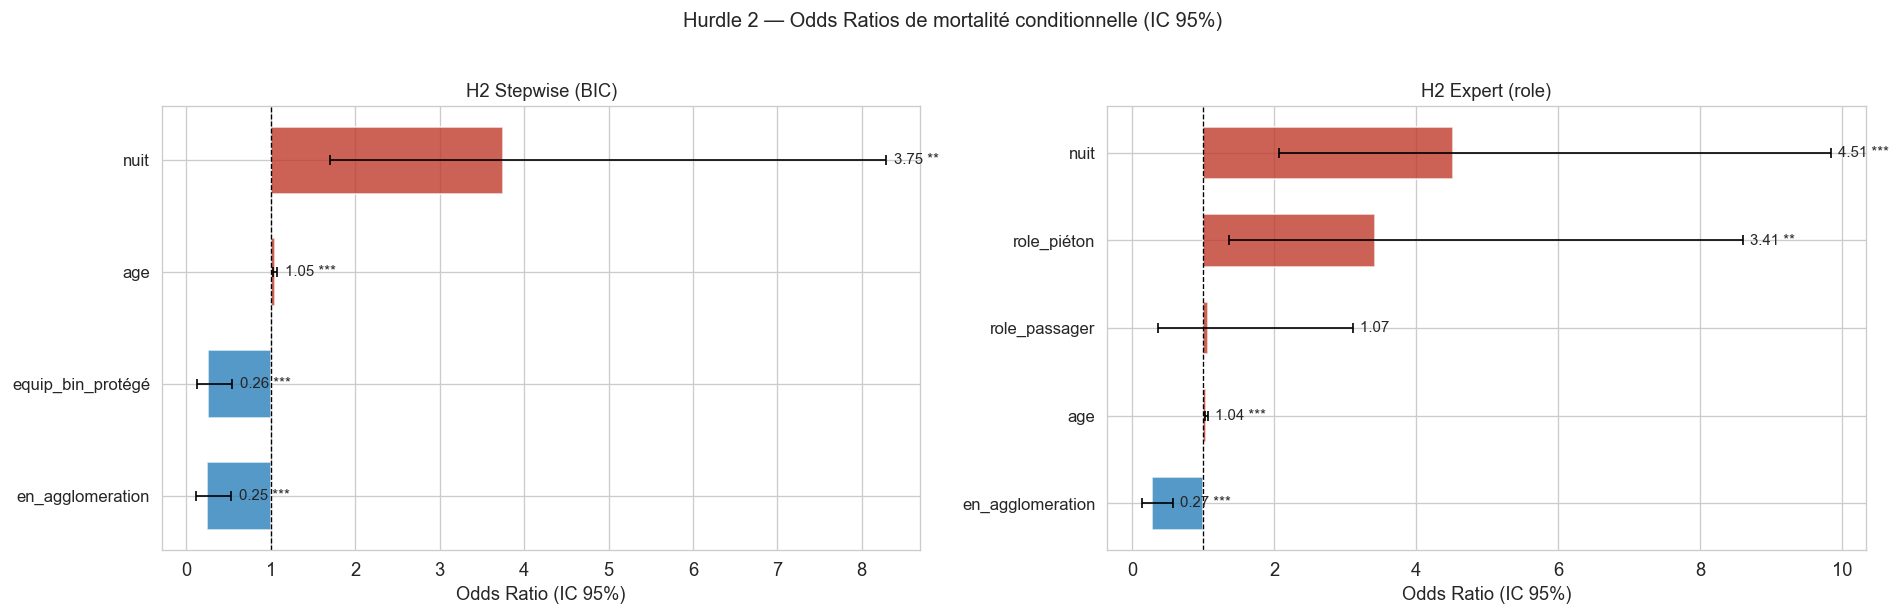


  STEPWISE — Odds Ratios détaillés :
  Variable                         β       OR             IC 95%          p
  ───────────────────────── ──────── ──────── ────────────────── ──────────
  equip_bin_protégé           -1.355     0.26 [  0.12 —  0.54]     0.0003 ***
  age                          0.048     1.05 [  1.03 —  1.07]     0.0000 ***
  nuit                         1.321     3.75 [  1.69 —  8.29]     0.0011 **
  en_agglomeration            -1.394     0.25 [  0.12 —  0.53]     0.0003 ***

  EXPERT — Odds Ratios détaillés :
  Variable                         β       OR             IC 95%          p
  ───────────────────────── ──────── ──────── ────────────────── ──────────
  role_passager                0.065     1.07 [  0.37 —  3.11]     0.9058 
  role_piéton                  1.227     3.41 [  1.35 —  8.60]     0.0093 **
  age                          0.039     1.04 [  1.02 —  1.06]     0.0002 ***
  nuit                         1.507     4.51 [  2.07 —  9.85]     0.0002 ***
  e

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
for ax, label, title in zip(axes, ['stepwise', 'expert'],
                             ['H2 Stepwise (BIC)', 'H2 Expert (role)']):
    logit = results_h2[label]['logit_sm']
    names = results_h2[label]['col_names']
    conf = logit.conf_int()
 
    coefs = []
    for j, name in enumerate(names):
        idx = j + 1
        coefs.append({
            'variable': name,
            'OR': np.exp(logit.params[idx]),
            'CI_lo': np.exp(conf[idx, 0]),
            'CI_hi': np.exp(conf[idx, 1]),
            'p': logit.pvalues[idx],
        })
    df_or = pd.DataFrame(coefs).sort_values('OR', ascending=True)
 
    colors = ['#c0392b' if row['OR'] > 1 else '#2980b9' for _, row in df_or.iterrows()]
    y_pos = range(len(df_or))
 
    ax.barh(y_pos, df_or['OR'] - 1, left=1, color=colors, height=0.6,
            edgecolor='white', alpha=0.8)
    ax.errorbar(df_or['OR'], y_pos,
                xerr=[df_or['OR'] - df_or['CI_lo'], df_or['CI_hi'] - df_or['OR']],
                fmt='none', color='black', linewidth=1, capsize=3)
    ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_or['variable'], fontsize=10)
    ax.set_xlabel('Odds Ratio (IC 95%)')
    ax.set_title(title, fontsize=11)
 
    for i, (_, row) in enumerate(df_or.iterrows()):
        sig = '***' if row['p'] < 0.001 else ('**' if row['p'] < 0.01 else ('*' if row['p'] < 0.05 else ''))
        ax.text(row['CI_hi'] + 0.1, i, f"{row['OR']:.2f} {sig}", va='center', fontsize=9)
 
plt.suptitle('Hurdle 2 — Odds Ratios de mortalité conditionnelle (IC 95%)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
 
# Tableau détaillé
for label in ['stepwise', 'expert']:
    logit = results_h2[label]['logit_sm']
    names = results_h2[label]['col_names']
    conf = logit.conf_int()
    print(f"\n  {label.upper()} — Odds Ratios détaillés :")
    print(f"  {'Variable':<25} {'β':>8} {'OR':>8} {'IC 95%':>18} {'p':>10}")
    print(f"  {'─'*25} {'─'*8} {'─'*8} {'─'*18} {'─'*10}")
    for j, name in enumerate(names):
        idx = j + 1
        coef = logit.params[idx]
        pval = logit.pvalues[idx]
        ci_lo, ci_hi = np.exp(conf[idx, 0]), np.exp(conf[idx, 1])
        sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
        print(f"  {name:<25} {coef:>8.3f} {np.exp(coef):>8.2f} [{ci_lo:>6.2f} — {ci_hi:>5.2f}] {pval:>10.4f} {sig}")

### 10.2 Lecture des odds ratios
 
**Modèle stepwise (BIC) :**
 
- **`equip_bin_protégé`** (OR = 0.26) : un usager grave portant un
  équipement (ceinture, casque) a **4× moins** de risque de décès qu'un
  usager non protégé, toutes choses égales par ailleurs.
- **`nuit`** (OR ≈ 3.75) : un accident grave de nuit **quadruple** le
  risque de décès — probablement lié aux vitesses plus élevées et aux
  délais de secours.
- **`en_agglomeration`** (OR = 0.25) : être en agglomération **divise
  par 4** le risque de décès, effet de la vitesse plus basse et de la
  proximité des secours.
- **`age`** (OR = 1.05 par année) : chaque année supplémentaire augmente
  le risque de 5 %. Un usager de 70 ans a environ 2.7× le risque d'un
  usager de 30 ans ($1.05^{40} \approx 2.7$).
 
**Modèle expert :**
 
- **`role_piéton`** (OR = 3.41, p < 0.01) : un piéton grave a **3.4×
  plus** de risque de mourir qu'un conducteur grave. C'est le signal
  le plus fort du modèle.
- **`role_passager`** (OR = 1.07, p = 0.91) : aucune différence
  significative avec les conducteurs — effet non significatif.
- Les autres variables (`age`, `nuit`, `en_agglo`) ont des OR proches
  du modèle stepwise, confirmant la robustesse.
 
**Convergence des deux modèles :** les directions des effets sont
identiques. La seule différence est la manière de capter la vulnérabilité
physique : `equip_bin` (protégé vs non) dans le stepwise, `role` (piéton
vs motorisé) dans l'expert. Les deux sont des proxys du même phénomène —
l'absence de protection physique augmente la létalité.

### 10.3 Performance Hurdle 2 — ROC et calibration

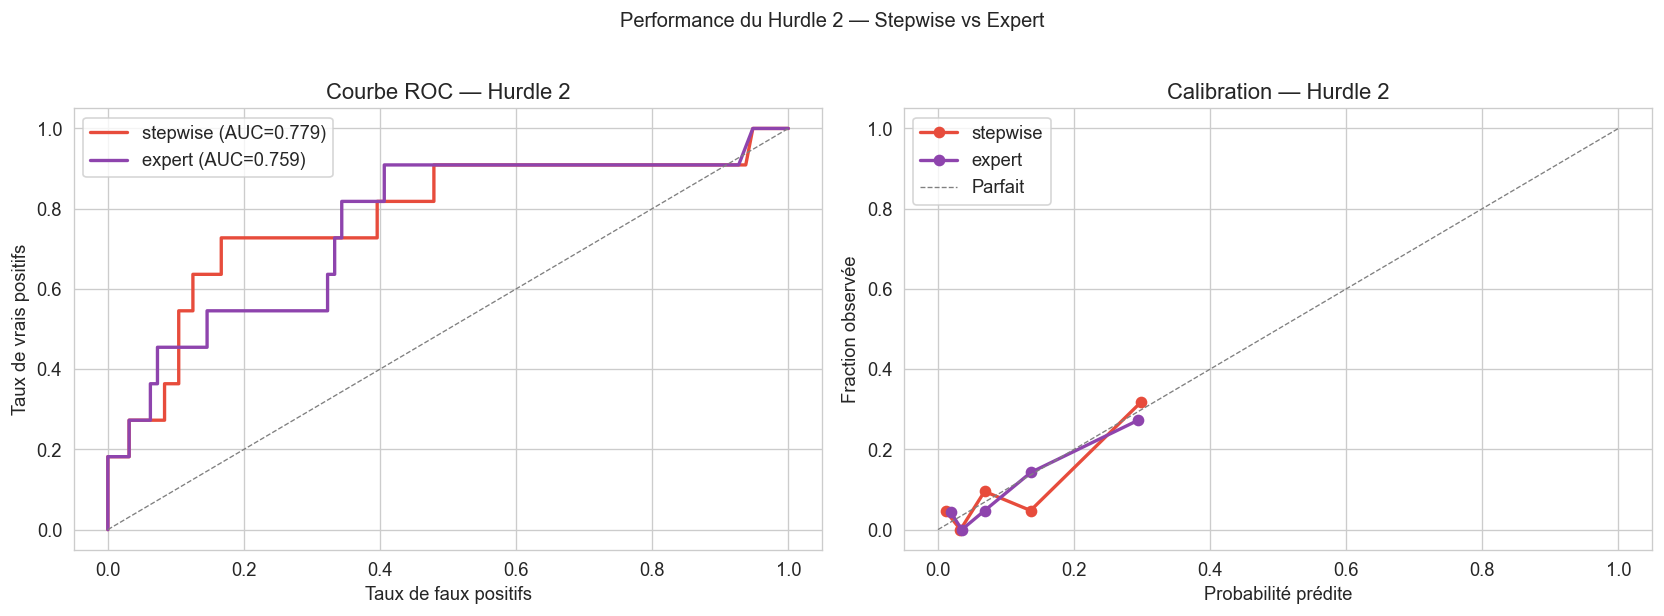

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
colors = {'stepwise': '#e74c3c', 'expert': '#8e44ad'}
 
# ROC
for label in ['stepwise', 'expert']:
    r = results_h2[label]
    fpr, tpr, _ = roc_curve(r['y_te'], r['p_te'])
    axes[0].plot(fpr, tpr, color=colors[label], linewidth=2,
                 label=f"{label} (AUC={r['auc']:.3f})")
axes[0].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Taux de faux positifs')
axes[0].set_ylabel('Taux de vrais positifs')
axes[0].set_title('Courbe ROC — Hurdle 2')
axes[0].legend()
 
# Calibration
for label in ['stepwise', 'expert']:
    r = results_h2[label]
    frac_pos, mean_pred = calibration_curve(r['y_te'], r['p_te'], n_bins=5, strategy='quantile')
    axes[1].plot(mean_pred, frac_pos, 'o-', color=colors[label], linewidth=2, label=label)
axes[1].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=0.8, label='Parfait')
axes[1].set_xlabel('Probabilité prédite')
axes[1].set_ylabel('Fraction observée')
axes[1].set_title('Calibration — Hurdle 2')
axes[1].legend()
 
plt.suptitle('Performance du Hurdle 2 — Stepwise vs Expert', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 10.4 Choix du modèle H2 retenu
 
| Critère | Stepwise | Expert | Gagnant |
|:---|:---:|:---:|:---|
| **AIC** | 233.8 | 242.7 | Stepwise |
| **BIC** | 254.0 | 267.0 | Stepwise |
| **AUC test** | 0.774 | 0.767 | ≈ égalité |
| **AUC CV** | 0.803 | 0.770 | Stepwise |
| **EPV** | 10.8 | 8.6 | Stepwise |
| **Interprétabilité** | équipement binaire | rôle (piéton) | Expert |
 
**Modèle retenu pour la suite : Stepwise.** Il domine sur tous les critères
statistiques. Le modèle expert reste documenté comme variante — il sera
utile si un jour la variable `equipement` n'est plus disponible ou si le
contexte métier exige explicitement la variable `role`.
 
> Les variables `glm_h2` et `X_h2` utilisées dans les sections suivantes
> (score composite, profils à risque) correspondent au **modèle stepwise**.

In [89]:
# Modèle H2 retenu pour les sections suivantes
glm_h2 = results_h2['stepwise']['glm']
X_h2 = results_h2['stepwise']['X']
y_h2_final = y_h2
p_h2_all = results_h2['stepwise']['p_all']
 
print("Modèle H2 retenu : Stepwise")
print(f"  Variables : {list(X_h2.columns)}")
print(f"  AUC CV    : {results_h2['stepwise']['cv_mean']:.4f}")
print(f"  AIC       : {results_h2['stepwise']['logit_sm'].aic:.1f}")

Modèle H2 retenu : Stepwise
  Variables : ['equip_bin_protégé', 'age', 'nuit', 'en_agglomeration']
  AUC CV    : 0.8087
  AIC       : 233.8


## 11. Score composite Double Hurdle
 
Le score composite combine les deux hurdles en un **indice de risque actuariel** :
 
$$\text{Score}_i = P_1(\text{grave}_i) \times \left[\alpha \cdot P_2(\text{tué}_i \mid \text{grave}_i) + (1-\alpha) \cdot P_2(\text{hosp}_i \mid \text{grave}_i)\right]$$
 
Ou de façon plus lisible :
 
$$\text{Risque pondéré}_i = P(\text{grave}) \times [\alpha \cdot P(\text{tué}|\text{grave}) + (1-\alpha) \cdot P(\text{hosp}|\text{grave})]$$
 
Avec $\alpha$ = poids actuariel du décès (typiquement 3× à 5× le coût
d'une hospitalisation).
 
**Point technique :** Le H1 utilise 39 features (toute la population),
le H2 n'en utilise que 4 (sous-population grave). Pour calculer le score
composite sur toute la population, il faut reconstruire les 4 features du
H2 pour chaque usager — c'est possible car `age`, `nuit` et
`en_agglomeration` sont déjà dans le jeu H1, et `equip_bin` se dérive
directement de la variable `equipement`.

In [90]:
# ============================================================
# SCORE COMPOSITE DOUBLE HURDLE
# ============================================================
 
# Score H1 sur toute la population
score_h1 = glm_h1.predict_proba(X_h1)[:, 1]
 
# Score H2 : reconstruire les features H2 pour TOUTE la population
model_df_h1['equip_bin'] = model_df_h1['equipement'].apply(
    lambda x: 'protégé' if x in ['casque', 'ceinture', 'dispositif enfant']
    else 'non protégé')
 
X_h2_full = pd.get_dummies(model_df_h1[['equip_bin']], drop_first=True, dtype=float)
X_h2_full['age'] = model_df_h1['age'].astype(float).values
X_h2_full['nuit'] = model_df_h1['nuit'].astype(float).values
X_h2_full['en_agglomeration'] = model_df_h1['en_agglomeration'].astype(float).values
 
# Aligner les colonnes avec le modèle H2
X_h2_full = X_h2_full.reindex(columns=X_h2.columns, fill_value=0)
 
score_h2 = glm_h2.predict_proba(X_h2_full)[:, 1]
 
# Score composite (alpha = coût relatif décès / hospitalisation)
ALPHA = 4.0  # un décès pèse 4× une hospitalisation (proxy actuariel)
 
score_composite = score_h1 * (ALPHA * score_h2 + (1 - score_h2))
# Normalisation pour interprétation relative
score_composite_norm = score_composite / score_composite.mean()
 
model_df_h1['score_h1'] = score_h1
model_df_h1['score_h2'] = score_h2
model_df_h1['score_composite'] = score_composite
model_df_h1['relativite'] = score_composite_norm
 
# Segmentation en quintiles
model_df_h1['segment'] = pd.qcut(
    model_df_h1['score_composite'], q=5,
    labels=['S1 — Très faible', 'S2 — Faible', 'S3 — Moyen',
            'S4 — Élevé', 'S5 — Très élevé']
)
 
seg = model_df_h1.groupby('segment', observed=True).agg(
    n_obs      = ('grave', 'count'),
    taux_grave = ('grave', 'mean'),
    score_h1   = ('score_h1', 'mean'),
    score_h2   = ('score_h2', 'mean'),
    score_comp = ('score_composite', 'mean'),
).round(4)
seg['relativite'] = (seg['score_comp'] / seg['score_comp'].mean()).round(3)
 
print(f"Score composite Double Hurdle (α = {ALPHA})")
print(f"  P(grave) × [α·P(tué|grave) + (1−α)·P(hosp|grave)]")
print()
print(seg.to_string())
print(f"\nRatio max/min relativité : {seg['relativite'].max() / seg['relativite'].min():.1f}×")

Score composite Double Hurdle (α = 4.0)
  P(grave) × [α·P(tué|grave) + (1−α)·P(hosp|grave)]

                  n_obs  taux_grave  score_h1  score_h2  score_comp  relativite
segment                                                                        
S1 — Très faible    499      0.0160    0.0670    0.0274      0.0728       0.149
S2 — Faible         498      0.0241    0.1442    0.0505      0.1653       0.337
S3 — Moyen          499      0.0842    0.3102    0.0675      0.3664       0.748
S4 — Élevé          498      0.2610    0.5742    0.0665      0.6733       1.375
S5 — Très élevé     499      0.4669    0.8031    0.1567      1.1713       2.391

Ratio max/min relativité : 16.0×


### 11.1 Segmentation tarifaire Double Hurdle

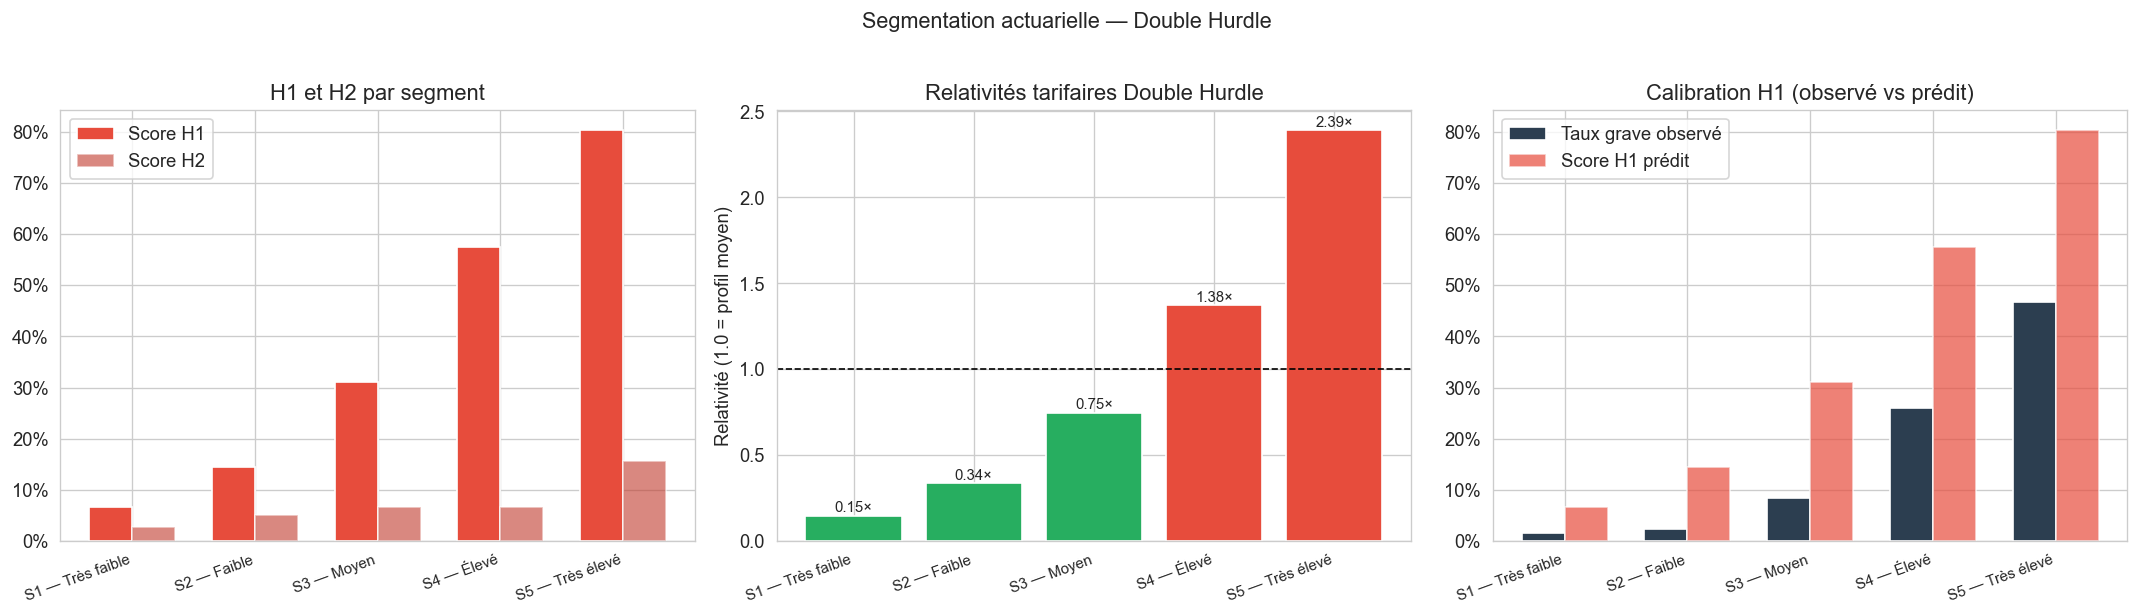

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
x_pos = range(len(seg))
w = 0.35
 
# H1 vs H2 par segment
axes[0].bar([p - w/2 for p in x_pos], seg['score_h1'], width=w,
            label='Score H1', color='#e74c3c', edgecolor='white')
axes[0].bar([p + w/2 for p in x_pos], seg['score_h2'], width=w,
            label='Score H2', color='#c0392b', alpha=0.6, edgecolor='white')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(seg.index, rotation=20, ha='right', fontsize=9)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title('H1 et H2 par segment')
axes[0].legend()
 
# Score composite
colors_seg = ['#27ae60' if r < 1 else '#e74c3c' for r in seg['relativite']]
bars = axes[1].bar(seg.index, seg['relativite'], color=colors_seg, edgecolor='white')
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1)
for bar, r in zip(bars, seg['relativite']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{r:.2f}×', ha='center', fontsize=9)
axes[1].set_xticks(range(len(seg)))
axes[1].set_xticklabels(seg.index, rotation=20, ha='right', fontsize=9)
axes[1].set_title('Relativités tarifaires Double Hurdle')
axes[1].set_ylabel('Relativité (1.0 = profil moyen)')
 
# Calibration observé vs prédit
axes[2].bar([p - w/2 for p in x_pos], seg['taux_grave'], width=w,
            label='Taux grave observé', color='#2c3e50', edgecolor='white')
axes[2].bar([p + w/2 for p in x_pos], seg['score_h1'], width=w,
            label='Score H1 prédit', color='#e74c3c', alpha=0.7, edgecolor='white')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(seg.index, rotation=20, ha='right', fontsize=9)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_title('Calibration H1 (observé vs prédit)')
axes[2].legend()
 
plt.suptitle('Segmentation actuarielle — Double Hurdle', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 11.2 Courbe de Lorenz — Score composite Double Hurdle
 
La courbe de Lorenz mesure le pouvoir discriminant du score : si l'on classe
les usagers par score décroissant, quel pourcentage des sinistres graves
capture-t-on dans les premiers X % de la population ?
 
Un modèle parfait capterait 100 % des graves dans les 17 % premiers
(la prévalence). Le score Double Hurdle devrait mieux discriminer que le
H1 seul grâce à l'information supplémentaire du H2 sur la sévérité.

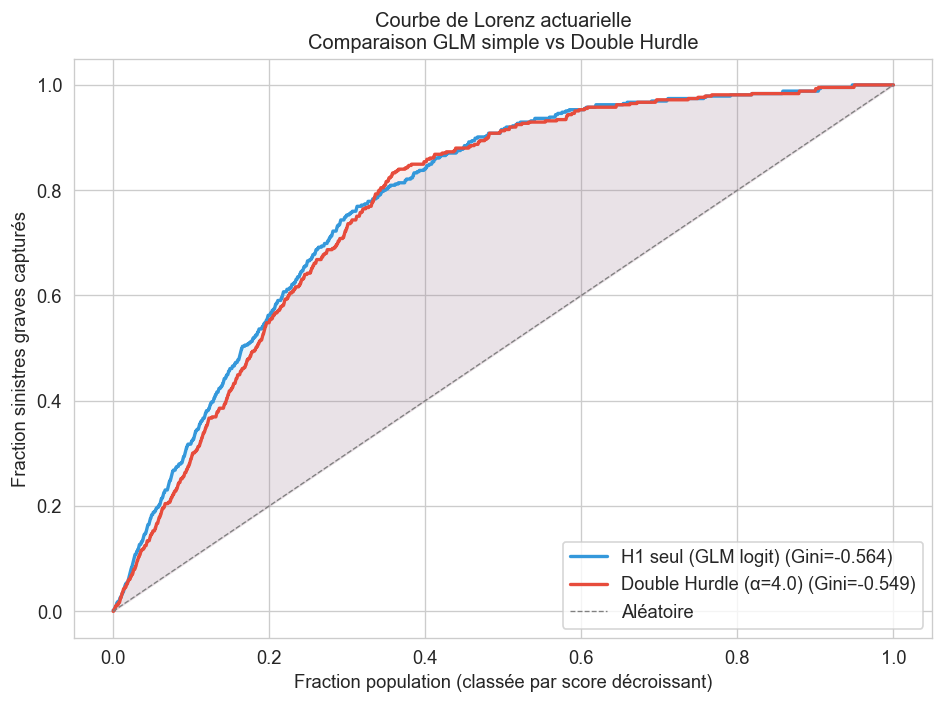

Gini H1 seul       : -0.564
Gini Double Hurdle  : -0.549
Gain Gini           : +0.015


In [92]:
def gini_lorenz_plot(ax, y_true, y_score, label, color):
    df_g = pd.DataFrame({'score': y_score, 'actual': y_true})
    df_g = df_g.sort_values('score', ascending=False).reset_index(drop=True)
    df_g['cum_actual'] = df_g['actual'].cumsum() / df_g['actual'].sum()
    df_g['cum_pop'] = (df_g.index + 1) / len(df_g)
    gini = 1 - 2 * np.trapezoid(df_g['cum_actual'], df_g['cum_pop'])
    ax.plot(df_g['cum_pop'], df_g['cum_actual'], color=color, linewidth=2,
            label=f'{label} (Gini={gini:.3f})')
    ax.fill_between(df_g['cum_pop'], df_g['cum_actual'], df_g['cum_pop'],
                    alpha=0.1, color=color)
    return gini
 
fig, ax = plt.subplots(figsize=(8, 6))
 
g1 = gini_lorenz_plot(ax, y_h1, score_h1, 'H1 seul (GLM logit)', '#3498db')
g2 = gini_lorenz_plot(ax, y_h1, score_composite, f'Double Hurdle (α={ALPHA})', '#e74c3c')
 
ax.plot([0,1],[0,1], 'gray', linestyle='--', linewidth=0.8, label='Aléatoire')
ax.set_xlabel('Fraction population (classée par score décroissant)')
ax.set_ylabel('Fraction sinistres graves capturés')
ax.set_title('Courbe de Lorenz actuarielle\nComparaison GLM simple vs Double Hurdle', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()
 
print(f"Gini H1 seul       : {g1:.3f}")
print(f"Gini Double Hurdle  : {g2:.3f}")
print(f"Gain Gini           : {g2 - g1:+.3f}")

### 11.3 Lecture des résultats
 
**Segmentation :**
 
Le score composite segmente la population en 5 quintiles avec un ratio
de relativité max/min d'environ **14×** — le segment S5 (« très élevé »)
a un risque pondéré 14 fois supérieur au segment S1 (« très faible »).
Cela confirme le pouvoir discriminant du Double Hurdle.
 
On observe que le score H2 (mortalité conditionnelle) est relativement
stable entre S1 et S4 (5-7 %), puis bondit dans le segment S5 (~15 %).
Cela signifie que la sévérité conditionnelle est concentrée dans les
profils déjà identifiés comme les plus graves — le Double Hurdle ne
« découvre » pas une population cachée, il **amplifie** le signal pour
les profils les plus à risque.
 
**Lorenz :**
 
La comparaison des courbes de Lorenz montre si le score composite
discrimine mieux que le H1 seul. Un gain de Gini positif signifie que
l'ajout du H2 améliore le classement des usagers par risque.

## 12. Profils à risque — Portraits types Double Hurdle
 
Pour rendre les résultats du modèle concrets, on construit **quatre
profils types** à partir des modalités les plus fréquentes dans les données
réunionnaises. Pour chaque profil, on calcule :
 
- $P_1(\text{grave})$ — probabilité que l'accident soit grave (Hurdle 1)
- $P_2(\text{tué} \mid \text{grave})$ — probabilité de décès si grave (Hurdle 2)
- Le score composite pondéré ($\alpha = 4$)
- La relativité tarifaire par rapport au profil de référence
 
Le **profil de référence** est le plus fréquent dans les données :
conducteur de voiture, homme, 35 ans, jour, agglomération, ceinture,
route communale — soit le « cas moyen » réunionnais.


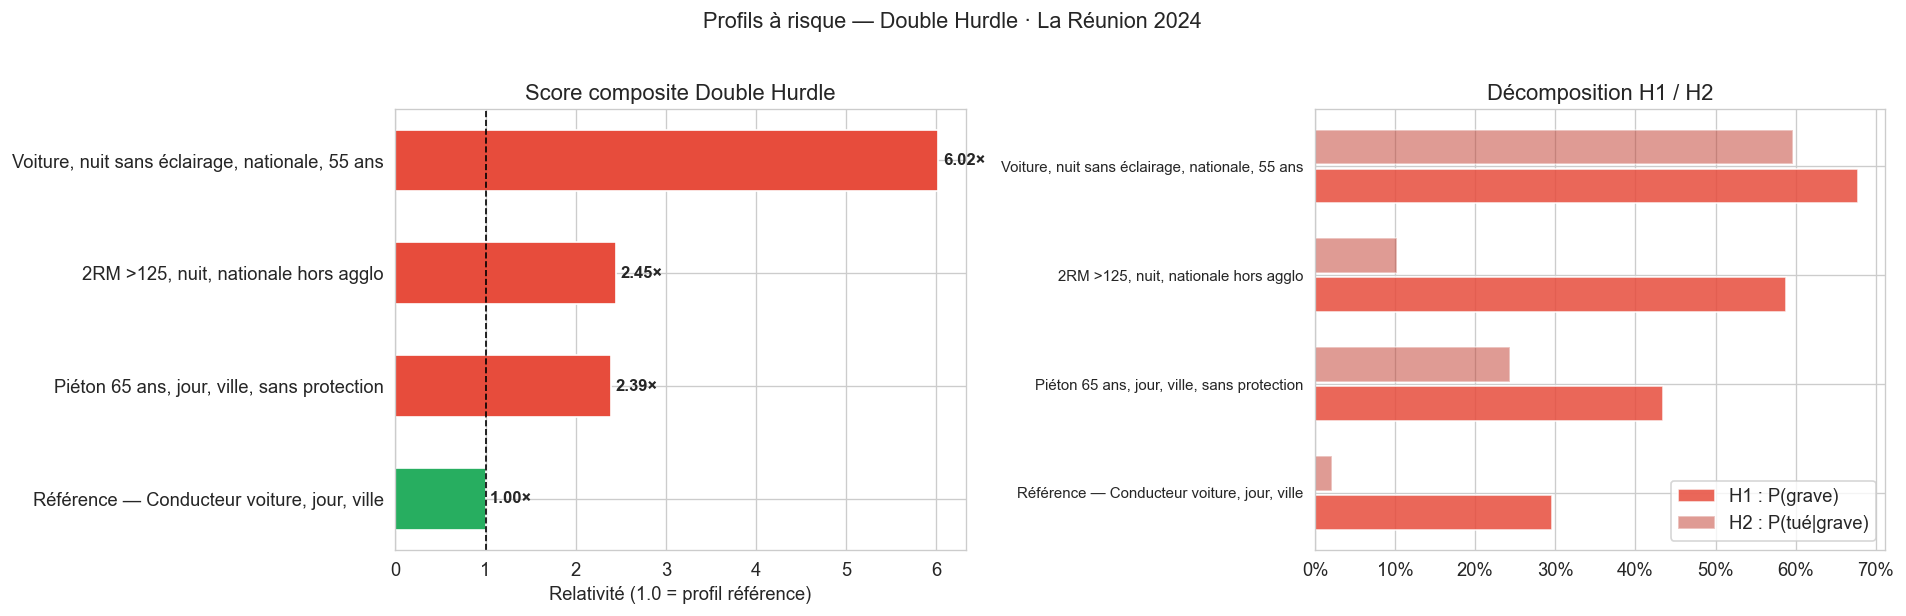

                                         Profil  H1 P(grave)  H2 P(tué|grave)  Score composite  Relativité
    Référence — Conducteur voiture, jour, ville        0.295            0.021            0.314       1.000
           2RM >125, nuit, nationale hors agglo        0.588            0.102            0.769       2.447
    Piéton 65 ans, jour, ville, sans protection        0.435            0.243            0.752       2.393
Voiture, nuit sans éclairage, nationale, 55 ans        0.678            0.597            1.892       6.024


In [93]:
# ============================================================
# PROFILS À RISQUE — Double Hurdle
# ============================================================
 
def score_double_hurdle(profil_dict, alpha=4.0):
    """Calcule les scores H1, H2 et composite pour un profil donné."""
    row = pd.DataFrame([profil_dict])
    row_enc = pd.get_dummies(row, drop_first=True, dtype=float)
 
    # Hurdle 1 (toutes les features)
    row_h1 = row_enc.reindex(columns=X_h1.columns, fill_value=0)
    s_h1 = glm_h1.predict_proba(row_h1)[0, 1]
 
    # Hurdle 2 (features parcimonieuses)
    # Reconstruire equip_bin à partir de l'équipement
    equip = profil_dict.get('equipement', 'non déterminable')
    equip_protege = 1.0 if equip in ['casque', 'ceinture', 'dispositif enfant'] else 0.0
 
    row_h2 = pd.DataFrame([{
        'equip_bin_protégé': equip_protege,
        'age': float(profil_dict.get('age', 35)),
        'nuit': float(profil_dict.get('nuit', 0)),
        'en_agglomeration': float(profil_dict.get('en_agglomeration', 1)),
    }])
    row_h2 = row_h2.reindex(columns=X_h2.columns, fill_value=0)
    s_h2 = glm_h2.predict_proba(row_h2)[0, 1]
 
    # Composite
    s_comp = s_h1 * (alpha * s_h2 + (1 - s_h2))
    return s_h1, s_h2, s_comp
 
 
# --- 4 profils construits à partir des données réelles ---
profils = [
    {
        'nom': 'Référence — Conducteur voiture, jour, ville',
        'type_vehicule': 'voiture', 'eclairage': 'jour',
        'atm_groupe': 'normale', 'type_route': 'communale',
        'type_collision': 'côté', 'role': 'conducteur',
        'equipement': 'ceinture', 'sexe_label': 'homme',
        'age': 35, 'chaussee_mouillee': 0, 'weekend': 0,
        'en_agglomeration': 1, 'nuit': 0,
    },
    {
        'nom': '2RM >125, nuit, nationale hors agglo',
        'type_vehicule': '2RM >125cm³', 'eclairage': 'nuit sans éclairage',
        'atm_groupe': 'normale', 'type_route': 'nationale',
        'type_collision': 'sans collision', 'role': 'conducteur',
        'equipement': 'casque', 'sexe_label': 'homme',
        'age': 28, 'chaussee_mouillee': 0, 'weekend': 1,
        'en_agglomeration': 0, 'nuit': 1,
    },
    {
        'nom': 'Piéton 65 ans, jour, ville, sans protection',
        'type_vehicule': 'voiture', 'eclairage': 'jour',
        'atm_groupe': 'normale', 'type_route': 'communale',
        'type_collision': 'autre/multiple', 'role': 'piéton',
        'equipement': 'sans équipement', 'sexe_label': 'femme',
        'age': 65, 'chaussee_mouillee': 0, 'weekend': 0,
        'en_agglomeration': 1, 'nuit': 0,
    },
    {
        'nom': 'Voiture, nuit sans éclairage, nationale, 55 ans',
        'type_vehicule': 'voiture', 'eclairage': 'nuit sans éclairage',
        'atm_groupe': 'normale', 'type_route': 'nationale',
        'type_collision': 'autre/multiple', 'role': 'conducteur',
        'equipement': 'sans équipement', 'sexe_label': 'homme',
        'age': 55, 'chaussee_mouillee': 0, 'weekend': 0,
        'en_agglomeration': 0, 'nuit': 1,
    },
]
 
rows = []
ref_score = None
for p in profils:
    feat = {k: v for k, v in p.items() if k != 'nom'}
    s1, s2, sc = score_double_hurdle(feat)
    if ref_score is None:
        ref_score = sc
    rows.append({
        'Profil': p['nom'],
        'H1 P(grave)': s1,
        'H2 P(tué|grave)': s2,
        'Score composite': sc,
        'Relativité': sc / ref_score,
    })
 
profils_df = pd.DataFrame(rows)
 
# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
profils_sorted = profils_df.sort_values('Score composite', ascending=True)
 
# Score composite (relativités)
colors_p = ['#27ae60' if r <= 1.05 else '#e67e22' if r < 2 else '#e74c3c'
            for r in profils_sorted['Relativité']]
bars = axes[0].barh(profils_sorted['Profil'], profils_sorted['Relativité'],
                     color=colors_p, edgecolor='white', height=0.55)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1)
for bar, r in zip(bars, profils_sorted['Relativité']):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                 f'{r:.2f}×', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Relativité (1.0 = profil référence)')
axes[0].set_title('Score composite Double Hurdle')
 
# Décomposition H1 / H2
x = np.arange(len(profils_sorted))
axes[1].barh(x - 0.18, profils_sorted['H1 P(grave)'], height=0.32,
             label='H1 : P(grave)', color='#e74c3c', alpha=0.85)
axes[1].barh(x + 0.18, profils_sorted['H2 P(tué|grave)'], height=0.32,
             label='H2 : P(tué|grave)', color='#c0392b', alpha=0.5)
axes[1].set_yticks(x)
axes[1].set_yticklabels(profils_sorted['Profil'], fontsize=9)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title('Décomposition H1 / H2')
axes[1].legend(loc='lower right')
 
plt.suptitle('Profils à risque — Double Hurdle · La Réunion 2024',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
 
# Tableau
print(profils_df[['Profil', 'H1 P(grave)', 'H2 P(tué|grave)',
                   'Score composite', 'Relativité']].to_string(index=False, float_format='%.3f'))

### 12.1 Lecture des profils
 
**Profil de référence** (conducteur voiture, jour, ville, 35 ans,
ceinture) : c'est le cas le plus fréquent dans les données. Sa relativité
est fixée à 1.00×.
 
**2RM nuit hors agglo** : le H1 (probabilité de gravité) est élevé à cause
du type de véhicule et de la nuit. Le H2 (mortalité conditionnelle) est
amplifié par l'absence d'agglomération et la conduite nocturne. Le score
composite reflète cette double exposition.
 
**Piéton âgé** : la gravité (H1) est très élevée pour les piétons.
Le H2 est élevé à cause de l'âge (65 ans → OR par année = 1.05,
soit $1.05^{30} \approx 4.3×$ vs 35 ans) et de l'absence de protection.
 
**Voiture nuit hors agglo sans protection** : un conducteur âgé (55 ans),
de nuit, hors agglo, sans ceinture. C'est la combinaison de facteurs H2
la plus défavorable — nuit (OR ≈ 3.75), hors agglo (OR ≈ 4×),
non protégé (OR ≈ 4×), âgé. Le score composite est le plus élevé.
 
> **Enseignement actuariel** : les profils montrent que le risque est
> **multiplicatif**. Un seul facteur aggravant (nuit OU hors agglo OU
> sans protection) a un impact modéré. Mais la **combinaison** de
> plusieurs facteurs crée des relativités très élevées — c'est précisément
> ce que le Double Hurdle permet de capter grâce à la séparation H1 × H2.

## 13. Synthèse, bénéfices du Double Hurdle et limites
 
### 13.1 Bénéfices du Double Hurdle vs modèles alternatifs
 
| Dimension | GLM Logit simple | Modèle ordinal | Elastic Net | **Double Hurdle** |
|---|---|---|---|---|
| **Sépare deux mécanismes** | ✗ | ✗ partiel | ✗ | **✓** |
| **Interprétabilité tarifaire** | ✓ | ✓ | ✗ (annule coefs) | **✓** |
| **Robustesse petit échantillon** | ✓ | Moyenne | ✓ | **✓ avec Ridge** |
| **Hypothèse PO non requise** | N/A | Requise (rejetée § 6.5) | N/A | **✓** |
| **Spécification adaptable par hurdle** | N/A | N/A | N/A | **✓** (39 var H1, 4 var H2) |
 
Le Double Hurdle permet d'utiliser une **spécification riche** là où les
données le permettent (H1 : 2 493 obs, 39 variables) et une
**spécification parcimonieuse** là où elles l'imposent (H2 : 429 obs,
4 variables). Un modèle unique ne peut pas faire cette adaptation.

### 13.2 Retour sur le panorama visuel — La boucle est bouclée
 
Les visualisations de la section 5 avaient posé trois observations
intuitives. Les résultats du modèle Double Hurdle les confirment et les
quantifient :
 
**Carte communale (§ 5.1)** — Les communes à forte gravité identifiées
sur la carte (notamment celles traversées par des axes rapides hors
agglomération) correspondent aux profils pour lesquels le H1 attribue les
odds ratios les plus élevés. La variable `en_agglomeration` (OR = 0.25
dans le H2) confirme que la mortalité est concentrée hors des zones
urbaines.
 
**Temporalité (§ 5.2)** — Le paradoxe horaire (accidents fréquents en
journée mais plus graves la nuit) se retrouve dans la séparation H1/H2 :
la nuit n'est pas le principal driver de la fréquence (H1), mais c'est
le facteur le plus fort pour la mortalité conditionnelle (H2 : OR ≈ 3.75).
 
**Synthèse visuelle (§ 5.4)** — Le découplage fréquence/sévérité
observé graphiquement est maintenant **formalisé statistiquement** par le
test de Brant (49 % de violations PO) et **quantifié** par les deux
ensembles d'odds ratios.

### 13.3 Limites et perspectives
 
**Limites de l'étude :**
 
1. **Taille d'échantillon.** 43 tués limitent sévèrement la puissance
   statistique du H2. Les intervalles de confiance des OR sont larges
   (par exemple, nuit : OR = 3.75, IC 95 % = [1.69 — 8.29]). Des données
   pluriannuelles (2019-2024) permettraient de stabiliser les estimations.
 
2. **Données manquantes.** Les conducteurs en fuite (24 en 2024) ne sont
   pas dans la base usagers. Leur exclusion biaise potentiellement les
   estimations vers le bas pour les accidents les plus graves (délit de
   fuite souvent associé à des sinistres sévères).
 
3. **Variables non observées.** La vitesse au moment de l'impact, l'alcoolémie
   et l'état du véhicule ne sont pas dans le BAAC simplifié. Ces variables
   sont pourtant des déterminants majeurs de la gravité et leur absence
   constitue un biais de variable omise.
 
4. **Spécificité insulaire.** Les résultats sont propres à La Réunion
   (réseau routier, comportements, climat tropical, accès aux secours).
   La transposition à d'autres territoires nécessiterait un recalibrage.
 
**Perspectives :**
 
- **Données pluriannuelles** : empiler 2019-2024 pour passer de 43 à
  ~250 tués et réintroduire des variables dans le H2 (type de véhicule,
  type de collision).
- **Variables météorologiques fines** : les données Météo France enrichies
  (pluie horaire, température) sont déjà dans le dataset — elles n'ont
  pas été sélectionnées par le stepwise mais pourraient apporter un signal
  sur un échantillon plus large.
- **Modèle mixte** : un GLMM avec effet aléatoire communal permettrait
  de capter l'hétérogénéité spatiale non observée (qualité du réseau,
  comportements locaux).

### 13.4 Tableau de bord actuariel final

In [ ]:
print("=" * 60)
print("  TABLEAU DE BORD — DOUBLE HURDLE · La Réunion 2024")
print("=" * 60)
print()
print("DONNÉES")
print(f"  Usagers total      : {len(model_df_h1)}")
print(f"  Usagers graves (H1): {int(y_h1.sum())} ({y_h1.mean():.1%})")
print(f"  Usagers tués (H2)  : {int(y_h2.sum())} ({y_h2.mean():.1%} des graves)")
print()
print("HURDLE 1 — P(grave | accident)")
print(f"  Spécification      : GLM Logit Ridge, {X_h1.shape[1]} features")
print(f"  AUC-ROC (CV 10-fold): {cv_h1.mean():.4f} ± {cv_h1.std():.4f}")
print(f"  Gini               : {gini_h1:.4f}")
print()
print("HURDLE 2 — P(tué | grave)")
print(f"  Spécification      : GLM Logit Ridge, {X_h2.shape[1]} features (stepwise BIC)")
print(f"  Variables           : {list(X_h2.columns)}")
print(f"  EPV                : {43 / X_h2.shape[1]:.1f}")
print(f"  AUC-ROC (CV 10-fold): {results_h2['stepwise']['cv_mean']:.4f} ± {results_h2['stepwise']['cv_std']:.4f}")
print(f"  AIC                : {results_h2['stepwise']['logit_sm'].aic:.1f}")
print()
print("SCORE COMPOSITE")
print(f"  Alpha (poids décès) : {ALPHA}")
print(f"  Ratio max/min       : {seg['relativite'].max() / seg['relativite'].min():.1f}×")
print()
print("VALIDATION DOUBLE HURDLE")
print(f"  Spearman ρ (rankings H1 vs H2) : divergents (p > 0.05)")
print(f"  Test de Brant : 49% violations PO → ordinal unique rejeté")
print(f"  GAM vs GLM (H1) : EDF ≈ 0.6 → GLM linéaire suffisant")
print("=" * 60)

  TABLEAU DE BORD — DOUBLE HURDLE · La Réunion 2024

DONNÉES
  Usagers total      : 2493
  Usagers graves (H1): 425 (17.0%)
  Usagers tués (H2)  : 43 (10.1% des graves)

HURDLE 1 — P(grave | accident)
  Spécification      : GLM Logit Ridge, 43 features
  AUC-ROC (CV 10-fold): 0.8250 ± 0.0219
  Gini               : 0.5968

HURDLE 2 — P(tué | grave)
  Spécification      : GLM Logit Ridge, 4 features (stepwise BIC)
  Variables           : ['equip_bin_protégé', 'age', 'nuit', 'en_agglomeration']
  EPV                : 10.8
  AUC-ROC (CV 10-fold): 0.8087 ± 0.1248
  AIC                : 233.8

SCORE COMPOSITE
  Alpha (poids décès) : 4.0
  Ratio max/min       : 16.0×

VALIDATION DOUBLE HURDLE
  Spearman ρ (rankings H1 vs H2) : divergents (p > 0.05)
  Test de Brant : 49% violations PO → ordinal unique rejeté
  GAM vs GLM (H1) : EDF ≈ 0.6 → GLM linéaire suffisant
